# Workflow Reservoir Simulator Development

Notebook ini mengikuti urutan `docs/workflow.md`:

1. Preparation
2. Connection List
3. Residual Calculation
4. Jacobian of Residual Function
5. Update Iteration
6. Check Residual and Numerical Constraints

Semua data kasus diambil dari project, tepatnya `manual_engine/run_manual.py`, lalu dipusatkan dalam `DataFrame` supaya alurnya tetap nyatu dan mudah ditelusuri per cell.

In [34]:
from __future__ import annotations

import numpy as np
import pandas as pd
from IPython.display import display

import manual_engine.run_manual as rm

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.0f}')

PVT_TABLES = {
    'bo': rm.PVT_BO,
    'bw': rm.PVT_BW,
    'bg': rm.PVT_BG,
    'mu_o': rm.PVT_MU_O,
    'mu_w': rm.PVT_MU_W,
    'mu_g': rm.PVT_MU_G,
}

ROCK_TABLES = {
    'kro': rm.ROCK_KRO,
    'krw': rm.ROCK_KRW,
    'krg': rm.ROCK_KRG,
    'pcow': rm.ROCK_PCOW,
    'pcgw': rm.ROCK_PCGW,
}

grid = rm.build_grid()

def make_lookup_df(table_name: str, rows: list[tuple[float, float]], x_name: str, y_name: str) -> pd.DataFrame:
    return pd.DataFrame(rows, columns=[x_name, y_name]).assign(table=table_name)

def state_to_df(state: dict, label: str) -> pd.DataFrame:
    df = pd.DataFrame({
        'cell': np.arange(1, len(state['p']) + 1),
        'pressure_psia': state['p'],
        'sw': state['sw'],
        'sg': state['sg'],
    })
    df['so'] = 1.0 - df['sw'] - df['sg']
    df['state'] = label
    return df[['state', 'cell', 'pressure_psia', 'sw', 'sg', 'so']]

def evaluate_state(grid: dict, state: dict) -> pd.DataFrame:
    rows = []
    for cell in grid['cells']:
        idx = cell['id']
        props = rm.cell_props(state['p'][idx], state['sw'][idx], state['sg'][idx])
        rows.append({
            'cell': idx + 1,
            'pressure_psia': state['p'][idx],
            'sw': state['sw'][idx],
            'sg': state['sg'][idx],
            'so': props['so'],
            'depth_ft': cell['depth'],
            'bulk_vol_ft3': cell['bulk_vol'],
            'poro': cell['poro'],
            'pore_volume_ft3': rm.pore_volume(cell, state['p'][idx]),
            **props,
        })
    return pd.DataFrame(rows)

def jacobian_labels(n_cells: int) -> tuple[list[str], list[str]]:
    row_labels = [f'R_o[{i}]' for i in range(1, n_cells + 1)]
    row_labels += [f'R_w[{i}]' for i in range(1, n_cells + 1)]
    row_labels += [f'R_g[{i}]' for i in range(1, n_cells + 1)]
    col_labels = [f'p[{i}]' for i in range(1, n_cells + 1)]
    col_labels += [f'Sw[{i}]' for i in range(1, n_cells + 1)]
    col_labels += [f'Sg[{i}]' for i in range(1, n_cells + 1)]
    return row_labels, col_labels


## Step 1 - Preparation

Tahap ini menyiapkan semua input dasar: data referensi, spesifikasi grid, solver, tabel PVT, tabel rock-fluid, dan grid cell aktif. Fokusnya sesuai bagian **§1 Unknown & Constraint** di `docs/rumuspenting.md`.

---

### Unknown & Constraint

Tiap cell reservoir memiliki **3 unknown utama** (*primary variables*) yang dicari tiap iterasi Newton:

| Unknown | Simbol | Satuan | Keterangan |
|---------|--------|--------|-----------|
| Tekanan | `p` | psia | Tekanan reservoir di pusat cell |
| Saturasi Air | `Sw` | fraksi | Fraksi pori yang terisi air |
| Saturasi Gas | `Sg` | fraksi | Fraksi pori yang terisi gas |

Saturasi minyak **bukan unknown** — dihitung langsung dari constraint kejenuhan pori:

$$S_o = 1 - S_w - S_g$$

Constraint ini harus selalu terpenuhi setelah setiap update Newton. Untuk grid dengan **N** cell total, sistem persamaan yang diselesaikan berukuran **3N × 3N**.

---

### Tabel PVT (Fungsi Tekanan `p`)

Semua properti fluida bergantung pada tekanan dan diinterpolasi linear dari tabel:

| Simbol | Nama | Catatan |
|--------|------|---------|
| `Bo` | Oil Formation Volume Factor (RB/STB) | Turun saat p naik di atas bubble point |
| `Bw` | Water Formation Volume Factor (RB/STB) | Hampir konstan (air ≈ incompressible) |
| `Bg` | Gas Formation Volume Factor (RB/Mscf) | Sangat sensitif terhadap p |
| `μo` | Oil Viscosity (cp) | Turun saat p naik |
| `μw` | Water Viscosity (cp) | Hampir konstan |
| `μg` | Gas Viscosity (cp) | Naik saat p naik |
| `Rso` | Solution GOR (scf/STB) | Gas terlarut dalam minyak — dipakai di akumulasi gas |

---

### Tabel Rock-Fluid (Fungsi Saturasi)

| Simbol | Indeks | Satuan | Keterangan |
|--------|--------|--------|-----------|
| `kro` | `So` (atau `Sw`) | fraksi | Relative perm minyak |
| `krw` | `Sw` | fraksi | Relative perm air |
| `krg` | `Sg` | fraksi | Relative perm gas |
| `Pcow` | `Sw` | psia | Capillary pressure oil-water |
| `Pcgw` | `Sg` | psia | Capillary pressure gas-water |

---

### Solver Configuration

| Parameter | Keterangan |
|-----------|-----------|
| `dt_initial` | Timestep awal — titik mulai sebelum adaptif |
| `dt_min` | Batas bawah — simulasi abort jika dt < dt_min |
| `max_time` | Total waktu simulasi |
| `growth_factor` | Pengali dt saat konvergen (> 1) |
| `shrink_factor` | Pengali dt saat gagal (< 1) |
| `max_newton_iter` | Batas iterasi Newton per timestep |
| `residual_tol` | Target residual norm ternormalisasi |
| `parameter_tol` | Target max perubahan `δp/p`, `δSw`, `δSg` |

In [35]:
df_reference = pd.DataFrame([
    {
        'reference_depth_ft': rm.REFERENCE_DEPTH,
        'reference_pressure_psia': rm.P_REF,
        'rho_oil_ref_lbm_ft3': rm.RHO_OIL_REF,
        'rho_water_ref_lbm_ft3': rm.RHO_WATER_REF,
        'rho_gas_ref_lbm_ft3': rm.RHO_GAS_REF,
        'rock_compressibility_psi_inv': rm.ROCK_COMPRESS,
    }
])

df_grid_spec = pd.DataFrame([
    {
        'nx': rm.NX,
        'ny': rm.NY,
        'nz': rm.NZ,
        'dx_ft': rm.DX,
        'dy_ft': rm.DY,
        'dz_ft': rm.DZ,
        'ngrid': rm.NX * rm.NY * rm.NZ,
        'porosity': rm.POROSITY,
        'perm_x_md': rm.PERM_X,
        'perm_y_md': rm.PERM_Y,
        'perm_z_md': rm.PERM_Z,
    }
])

df_solver = pd.DataFrame([
    {
        'dt_initial_day': rm.DT_INITIAL,
        'dt_min_day': rm.DT_MIN,
        'max_time_day': rm.MAX_TIME,
        'growth_factor': rm.GROWTH_FACTOR,
        'shrink_factor': rm.SHRINK_FACTOR,
        'max_retries': rm.MAX_RETRIES,
        'max_newton_iter': rm.MAX_NEWTON_ITER,
        'residual_tol': rm.RESID_TOL,
        'parameter_tol': rm.PARAM_TOL,
    }
])

df_pvt = pd.concat(
    [make_lookup_df(name, rows, 'pressure_psia', 'value') for name, rows in PVT_TABLES.items()],
    ignore_index=True,
)[['table', 'pressure_psia', 'value']]

df_rock = pd.concat(
    [make_lookup_df(name, rows, 'saturation', 'value') for name, rows in ROCK_TABLES.items()],
    ignore_index=True,
)[['table', 'saturation', 'value']]

df_cells = pd.DataFrame(grid['cells']).rename(columns={
    'id': 'cell_id',
    'i': 'i_index',
    'j': 'j_index',
    'k': 'k_index',
    'depth': 'depth_ft',
    'bulk_vol': 'bulk_vol_ft3',
    'kx': 'kx_md',
    'ky': 'ky_md',
    'kz': 'kz_md',
}).assign(cell=lambda d: d['cell_id'] + 1)
df_cells = df_cells[['cell', 'cell_id', 'i_index', 'j_index', 'k_index', 'depth_ft', 'bulk_vol_ft3', 'poro', 'kx_md', 'ky_md', 'kz_md']]

display(df_reference)
display(df_grid_spec)
display(df_solver)
display(df_cells.head())
display(df_pvt.head(12))
display(df_rock.head(12))


,reference_depth_ft,reference_pressure_psia,rho_oil_ref_lbm_ft3,rho_water_ref_lbm_ft3,rho_gas_ref_lbm_ft3,rock_compressibility_psi_inv
0,"5,000","3,000",50,62,1,0


,nx,ny,nz,dx_ft,dy_ft,dz_ft,ngrid,porosity,perm_x_md,perm_y_md,perm_z_md
0,5,5,1,500,500,50,25,0,100,100,0


,dt_initial_day,dt_min_day,max_time_day,growth_factor,shrink_factor,max_retries,max_newton_iter,residual_tol,parameter_tol
0,1,0,5,1,0,5,15,0,0


,cell,cell_id,i_index,j_index,k_index,depth_ft,bulk_vol_ft3,poro,kx_md,ky_md,kz_md
0,1,0,0,0,0,"5,025","12,500,000",0,100,100,0
1,2,1,1,0,0,"5,025","12,500,000",0,100,100,0
2,3,2,2,0,0,"5,025","12,500,000",0,100,100,0
3,4,3,3,0,0,"5,025","12,500,000",0,100,100,0
4,5,4,4,0,0,"5,025","12,500,000",0,100,100,0


,table,pressure_psia,value
0,bo,500,1
1,bo,"1,000",1
2,bo,"2,000",1
3,bo,"3,000",1
4,bo,"4,000",1
5,bo,"5,000",1
6,bw,500,1
7,bw,"1,000",1
8,bw,"2,000",1
9,bw,"3,000",1


,table,saturation,value
0,kro,0,1
1,kro,0,1
2,kro,0,1
3,kro,0,0
4,kro,1,0
5,kro,1,0
6,kro,1,0
7,krw,0,0
8,krw,0,0
9,krw,0,0


## Step 2 - Connection List

Tahap ini membangun daftar semua **koneksi antar cell** (pasangan sel yang bersentuhan) dan menghitung **transmissibility** geometrik untuk setiap koneksi. Sesuai §2 `docs/rumuspenting.md`.

---

### Transmissibility Geometrik

Transmissibility adalah ukuran "kemudahan fluida mengalir" antara dua cell berdekatan. Nilainya murni geometri dan properti batuan — **tidak bergantung pada saturasi maupun tekanan fluida**.

$$T_{12} = 0.00603 \cdot \frac{2 k_1 k_2}{k_1 + k_2} \cdot \frac{A}{\Delta x}$$

| Simbol | Nama | Satuan | Keterangan |
|--------|------|--------|-----------|
| `0.00603` | Faktor konversi field unit | — | Konversi mD·ft²/ft → RB·cp/(psi·day) |
| `k₁, k₂` | Permeabilitas absolut cell 1 dan 2 | mD | Harmonic mean agar bottleneck layer yang dominan |
| `A` | Luas penampang bidang kontak | ft² | `dy × dz` untuk koneksi arah-X |
| `Δx` | Jarak total antara pusat kedua cell | ft | `dx₁/2 + dx₂/2` |

**Kenapa harmonic mean?** Dua cell dengan permeabilitas berbeda tersusun seri. Hambatan total dua resistor seri = jumlah resistansinya, yang setara dengan harmonic mean permeabilitas:
$$\frac{\Delta x_{total}}{k_{harm}} = \frac{\Delta x_1}{k_1} + \frac{\Delta x_2}{k_2} \implies k_{harm} = \frac{2 k_1 k_2}{k_1 + k_2}$$

---

### Mobility Fluida — M = kr / (μ · B)

Mobility menggabungkan properti batuan dan fluida menjadi satu koefisien yang menentukan kemudahan tiap fasa mengalir:

$$M_o = \frac{k_{ro}(S_o)}{\mu_o \cdot B_o}, \quad M_w = \frac{k_{rw}(S_w)}{\mu_w \cdot B_w}, \quad M_g = \frac{k_{rg}(S_g)}{\mu_g \cdot B_g}$$

| Suku | Pengaruh | Makin besar jika |
|------|----------|-----------------|
| `krα` | Relative perm fasa α | Saturasi fasa itu tinggi |
| `μα` | Viskositas (penyebut) | Makin kecil = makin mudah mengalir |
| `Bα` | Formation volume factor (penyebut) | Menjembatani satuan reservoir ↔ surface |

**Kenapa ada B di penyebut?** Residual material balance ditulis dalam satuan **surface** (STB/day), sedangkan tekanan dan saturasi bekerja di satuan **reservoir**. Faktor B mengkonversi: `q_surface = q_reservoir / B`.

**Upwind weighting:** Mobility selalu diambil dari cell *upstream* (cell dengan tekanan lebih tinggi). Ini menjamin stabilitas numerik — jika diambil dari downstream, skema bisa osilasi.

---

### Flow Rate Per Koneksi (tanpa gravitasi)

Setelah T dan M diketahui, flow rate fasa dari cell j ke cell i:

$$q_{\alpha,ji} = T_{ij} \cdot M_\alpha^{upwind} \cdot (p_j - p_i)$$

- Positif → fluida mengalir **masuk** ke cell i
- Negatif → fluida mengalir **keluar** dari cell i

Net flux ke cell i = jumlah semua koneksinya:

$$NF_{\alpha,i} = \sum_{j \in \text{neighbors}(i)} q_{\alpha,ji}$$

  GRID MATRIX  (5 x 5)  
   1  2  3  4  5
   6  7  8  9 10
  11 12 13 14 15
  16 17 18 19 20
  21 22 23 24 25

=== Koneksi aktual — 12 baris pertama ===


,connection,from_cell,to_cell,dir,area,dist,harmonic_perm_md,T,transmissibility_check
0,1,1,2,x,"25,000",500,100,30,30
1,2,1,6,y,"25,000",500,100,30,30
2,3,2,3,x,"25,000",500,100,30,30
3,4,2,7,y,"25,000",500,100,30,30
4,5,3,4,x,"25,000",500,100,30,30
5,6,3,8,y,"25,000",500,100,30,30
6,7,4,5,x,"25,000",500,100,30,30
7,8,4,9,y,"25,000",500,100,30,30
8,9,5,10,y,"25,000",500,100,30,30
9,10,6,7,x,"25,000",500,100,30,30



=== Jumlah koneksi per cell ===


,cell,n_connections
0,1,2
1,2,3
2,3,3
3,4,3
4,5,2
5,6,3
6,7,4
7,8,4
8,9,4
9,10,3



=== Tetangga cell 7 ===


,cell,tetangga,arah,conn_dir,T
0,7,2,atas (j-1),y,30
1,7,6,kiri (i-1),x,30
2,7,8,kanan (i+1),x,30
3,7,12,bawah (j+1),y,30



=== Connection List lengkap ===


,statement
0,grid 1 connected to grid 2 dan grid 6
1,"grid 2 connected to grid 1, grid 3, dan grid 7"
2,"grid 3 connected to grid 2, grid 4, dan grid 8"
3,"grid 4 connected to grid 3, grid 5, dan grid 9"
4,grid 5 connected to grid 4 dan grid 10
5,"grid 6 connected to grid 1, grid 7, dan grid 11"
6,"grid 7 connected to grid 2, grid 6, grid 8, da..."
7,"grid 8 connected to grid 3, grid 7, grid 9, da..."
8,"grid 9 connected to grid 4, grid 8, grid 10, d..."
9,"grid 10 connected to grid 5, grid 9, dan grid 15"


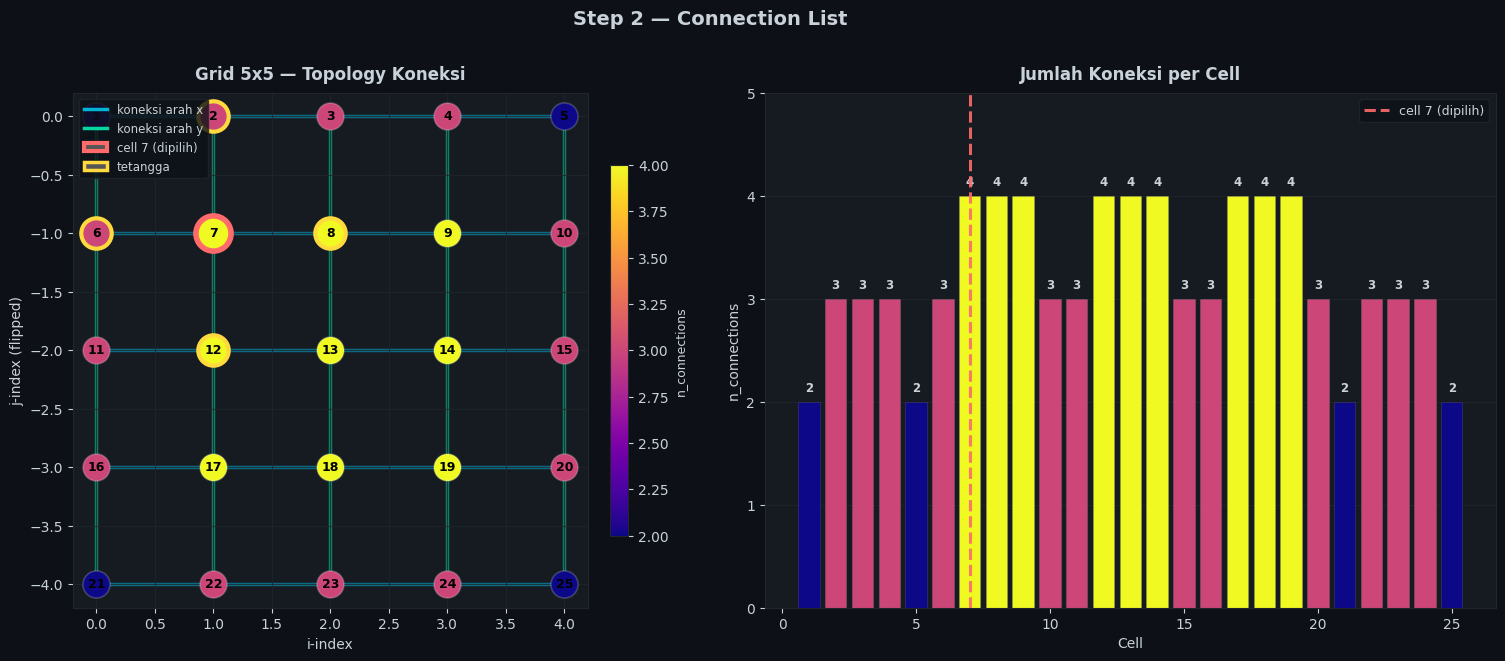

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

perm_map = {'x': rm.PERM_X, 'y': rm.PERM_Y, 'z': rm.PERM_Z}

df_connections = pd.DataFrame(grid['connections']).copy()
df_connections['connection'] = np.arange(1, len(df_connections) + 1)
df_connections['from_cell'] = df_connections['from'] + 1
df_connections['to_cell']   = df_connections['to']   + 1
df_connections['harmonic_perm_md'] = df_connections['dir'].map(perm_map)
df_connections['transmissibility_check'] = (
    rm.TRANSMISSIBILITY_UNIT_FACTOR
    * df_connections['harmonic_perm_md']
    * df_connections['area']
    / df_connections['dist']
)
df_connections = df_connections[[
    'connection', 'from_cell', 'to_cell', 'dir', 'area', 'dist',
    'harmonic_perm_md', 'T', 'transmissibility_check'
]]

df_connection_count = pd.concat([
    df_connections[['from_cell']].rename(columns={'from_cell': 'cell'}),
    df_connections[['to_cell']].rename(columns={'to_cell': 'cell'}),
], ignore_index=True).value_counts().rename('n_connections').reset_index()


def build_connection_map(df: pd.DataFrame, n_cells: int) -> dict[int, list[int]]:
    conn_map = {cell: [] for cell in range(1, n_cells + 1)}
    for _, row in df.iterrows():
        f, t = int(row['from_cell']), int(row['to_cell'])
        conn_map[f].append(t)
        conn_map[t].append(f)
    for cell in conn_map:
        conn_map[cell] = sorted(set(conn_map[cell]))
    return conn_map


def build_grid_matrix(cells_df: pd.DataFrame, nx: int, ny: int) -> np.ndarray:
    matrix = np.zeros((ny, nx), dtype=int)
    for _, row in cells_df.iterrows():
        matrix[int(row['j_index']), int(row['i_index'])] = int(row['cell'])
    return matrix


_DIR_LABEL = {
    (-1,  0,  0): 'kiri     (i-1)',
    ( 1,  0,  0): 'kanan    (i+1)',
    ( 0, -1,  0): 'atas     (j-1)',
    ( 0,  1,  0): 'bawah    (j+1)',
    ( 0,  0, -1): 'belakang (k-1)',
    ( 0,  0,  1): 'depan    (k+1)',
}


def describe_neighbors(cell_number: int) -> pd.DataFrame:
    mask = (df_connections['from_cell'] == cell_number) | (df_connections['to_cell'] == cell_number)
    cell_conns = df_connections[mask].copy()
    target = df_cells.loc[df_cells['cell'] == cell_number].iloc[0]
    rows = []
    for _, conn in cell_conns.iterrows():
        neighbor = int(conn['to_cell'] if conn['from_cell'] == cell_number else conn['from_cell'])
        nbr = df_cells.loc[df_cells['cell'] == neighbor].iloc[0]
        delta = (
            int(nbr['i_index'] - target['i_index']),
            int(nbr['j_index'] - target['j_index']),
            int(nbr['k_index'] - target['k_index']),
        )
        rows.append({
            'cell': cell_number,
            'tetangga': neighbor,
            'arah': _DIR_LABEL.get(delta, 'terhubung'),
            'conn_dir': conn['dir'],
            'T': conn['T'],
        })
    return pd.DataFrame(rows).sort_values('tetangga').reset_index(drop=True)


def format_connection_list(conn_map: dict[int, list[int]]) -> pd.DataFrame:
    rows = []
    for cell, neighbors in sorted(conn_map.items()):
        parts = [f'grid {n}' for n in neighbors]
        if not parts:
            desc = '(tidak ada)'
        elif len(parts) == 1:
            desc = parts[0]
        elif len(parts) == 2:
            desc = f'{parts[0]} dan {parts[1]}'
        else:
            last = parts[-1]  # pisahkan dulu agar tidak ada backslash di dalam f-string
            desc = ', '.join(parts[:-1]) + f', dan {last}'
        rows.append({'cell': cell, 'statement': f'grid {cell} connected to {desc}'})
    return pd.DataFrame(rows)


connection_map = build_connection_map(df_connections, len(df_cells))
grid_matrix    = build_grid_matrix(df_cells, rm.NX, rm.NY)

# ============================================================
cell_to_check = 7   # <-- ganti nomor cell di sini
# ============================================================

df_neighbors       = describe_neighbors(cell_to_check)
df_connection_list = format_connection_list(connection_map)
neighbors_set      = set(connection_map.get(cell_to_check, []))

# Grid matrix (teks)
col_w = len(str(rm.NX * rm.NY)) + 1
print("=" * (col_w * rm.NX + 2))
print(f"  GRID MATRIX  ({rm.NX} x {rm.NY})  ".center(col_w * rm.NX + 2))
print("=" * (col_w * rm.NX + 2))
for j in range(rm.NY):
    print(" " + "".join(str(grid_matrix[j, i]).rjust(col_w) for i in range(rm.NX)))
print()

print("=== Koneksi aktual — 12 baris pertama ===")
display(df_connections.head(12))
print(f"\n=== Jumlah koneksi per cell ===")
display(df_connection_count.sort_values('cell').reset_index(drop=True))
print(f"\n=== Tetangga cell {cell_to_check} ===")
display(df_neighbors)
print(f"\n=== Connection List lengkap ===")
display(df_connection_list[['statement']])

# ── Visualisasi: dark theme ──────────────────────────────────
BG, PANEL = '#0d1117', '#161b22'
TEXT, GRID_C = '#c9d1d9', '#21262d'
C_SEL, C_NBR = '#ff6b6b', '#ffd93d'
DIR_CLR = {'x': '#00b4d8', 'y': '#06d6a0'}

cmap     = plt.cm.plasma
ncon_map = df_connection_count.set_index('cell')['n_connections']
vmin_nc  = df_connection_count['n_connections'].min()
vmax_nc  = df_connection_count['n_connections'].max()
norm_nc  = plt.Normalize(vmin=vmin_nc, vmax=vmax_nc)

df_grid_plot = df_cells.assign(x=df_cells['i_index'], y=-df_cells['j_index'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor(BG)

for ax in axes:
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color(GRID_C)
    ax.tick_params(colors=TEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)

# ── Plot 1: Grid topology ─────────────────────────────────────
for _, conn in df_connections.iterrows():
    p1 = df_grid_plot.loc[df_grid_plot['cell'] == conn['from_cell'], ['x', 'y']].iloc[0]
    p2 = df_grid_plot.loc[df_grid_plot['cell'] == conn['to_cell'],   ['x', 'y']].iloc[0]
    axes[0].plot([p1['x'], p2['x']], [p1['y'], p2['y']],
                 color=DIR_CLR.get(conn['dir'], '#aaa'), alpha=0.55, lw=2.5, zorder=1)

for _, row in df_grid_plot.iterrows():
    c          = int(row['cell'])
    node_color = cmap(norm_nc(ncon_map.get(c, vmin_nc)))
    if c == cell_to_check:
        ec, lw_s, sz = C_SEL, 4.0, 640
    elif c in neighbors_set:
        ec, lw_s, sz = C_NBR, 3.0, 480
    else:
        ec, lw_s, sz = '#ffffff33', 1.2, 380
    axes[0].scatter(row['x'], row['y'], s=sz,
                    color=node_color, edgecolors=ec, linewidths=lw_s, zorder=3)
    axes[0].text(row['x'], row['y'], c,
                 ha='center', va='center', fontsize=9, fontweight='bold',
                 color='black', zorder=4)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_nc)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[0], shrink=0.72, pad=0.03)
cbar.set_label('n_connections', color=TEXT, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)
cbar.outline.set_edgecolor(GRID_C)

legend_handles = [
    Line2D([0], [0], color=DIR_CLR['x'], lw=2.5, label='koneksi arah x'),
    Line2D([0], [0], color=DIR_CLR['y'], lw=2.5, label='koneksi arah y'),
    mpatches.Patch(facecolor='#555', edgecolor=C_SEL, linewidth=3,  label=f'cell {cell_to_check} (dipilih)'),
    mpatches.Patch(facecolor='#555', edgecolor=C_NBR, linewidth=2.5, label='tetangga'),
]
axes[0].legend(handles=legend_handles, fontsize=8.5,
               facecolor='#0d1117', edgecolor=GRID_C, labelcolor=TEXT, loc='upper left')
axes[0].set_title(f'Grid {rm.NX}x{rm.NY} — Topology Koneksi', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('i-index', fontsize=10)
axes[0].set_ylabel('j-index (flipped)', fontsize=10)
axes[0].grid(True, color=GRID_C, alpha=0.8, lw=0.8)
axes[0].set_aspect('equal', adjustable='box')

# ── Plot 2: Bar chart ──────────────────────────────────────────
sorted_count = df_connection_count.sort_values('cell').reset_index(drop=True)
bar_colors   = [cmap(norm_nc(n)) for n in sorted_count['n_connections']]

bars = axes[1].bar(sorted_count['cell'], sorted_count['n_connections'],
                   color=bar_colors, edgecolor='#ffffff18', linewidth=0.8, zorder=2)

for bar, val in zip(bars, sorted_count['n_connections']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.07,
                 str(int(val)), ha='center', va='bottom',
                 fontsize=8.5, fontweight='bold', color=TEXT)

axes[1].axvline(x=cell_to_check, color=C_SEL, lw=2.2, ls='--', alpha=0.9,
                label=f'cell {cell_to_check} (dipilih)', zorder=3)
axes[1].set_title('Jumlah Koneksi per Cell', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Cell', fontsize=10)
axes[1].set_ylabel('n_connections', fontsize=10)
axes[1].set_ylim(0, sorted_count['n_connections'].max() + 1.0)
axes[1].grid(True, axis='y', color=GRID_C, alpha=0.8, lw=0.8, zorder=1)
axes[1].legend(fontsize=9, facecolor='#0d1117', edgecolor=GRID_C, labelcolor=TEXT)

fig.suptitle('Step 2 — Connection List', color=TEXT, fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 3 - Residual Calculation

Tahap ini menghitung **residual** untuk setiap cell — selisih antara net flux masuk dan perubahan inventori fluida (akumulasi). Residual harus = 0 saat konvergensi Newton. Sesuai §3, §4, dan §5 `docs/rumuspenting.md`.

---

### Konsep Residual — Material Balance Per Cell

Residual adalah ukuran "seberapa tidak-balance" suatu cell. Kalau residual = 0 → konservasi massa terpenuhi sempurna untuk fasa itu.

$$R_\alpha = \underbrace{\sum_j T_{ij} \cdot M_\alpha^{upwind} \cdot (p_j - p_i)}_{\text{Net Flux}} - \underbrace{\frac{1}{\Delta t}\left[\frac{V_p S_\alpha^k}{B_\alpha^k} - \frac{V_p S_\alpha^n}{B_\alpha^n}\right]}_{\text{Akumulasi}} - \underbrace{q_\alpha}_{\text{Well Term (=0 jika tidak ada sumur)}}$$

---

### Residual Oil

$$R_o = \sum_j T_{ij} \cdot M_o^k \cdot (p_j - p_i)^k - \frac{1}{\Delta t}\left[\frac{V_p S_o^k}{B_o^k} - \frac{V_p S_o^n}{B_o^n}\right] - q_o$$

- `So^k = 1 - Sw^k - Sg^k` (constraint, bukan unknown)
- Akumulasi positif = inventori minyak **bertambah** → perlu net flux masuk yang sama

---

### Residual Water

$$R_w = \sum_j T_{ij} \cdot M_w^k \cdot (p_j - p_i)^k - \frac{1}{\Delta t}\left[\frac{V_p S_w^k}{B_w^k} - \frac{V_p S_w^n}{B_w^n}\right]$$

- Air diasumsikan tidak diproduksi (`qw = 0`) di kasus dasar ini

---

### Residual Gas — Perhatikan Suku Gas Terlarut!

$$R_g = \sum_j T_{ij} \cdot M_g^k \cdot (p_j - p_i)^k - \frac{1}{\Delta t}\left[\frac{V_p S_g^k}{B_g^k} + R_{so}^k \frac{V_p S_o^k}{B_o^k} - \frac{V_p S_g^n}{B_g^n} - R_{so}^n \frac{V_p S_o^n}{B_o^n}\right] - q_g$$

Akumulasi gas punya **dua suku**:
- `Sg/Bg` → gas bebas di ruang pori
- `Rso·So/Bo` → gas yang **terlarut di minyak** (solution gas) — ikut berpindah bersama minyak

Dalam kasus ini `Rso = 0` (tabel belum diisi) sehingga suku gas terlarut hilang, tapi kolom dekomposisinya tetap ditampilkan untuk transparansi.

---

### Potential Aliran (dengan Kapiler dan Gravitasi)

Driving force aliran bukan hanya beda tekanan, tapi juga kapiler dan gravitasi:

$$\Phi_o = p_j - p_i - \rho_o \cdot g \cdot (z_j - z_i) / 144$$
$$\Phi_w = (p_j - P_{cow,j}) - (p_i - P_{cow,i}) - \rho_w \cdot g \cdot (z_j - z_i) / 144$$
$$\Phi_g = (p_j + P_{cgw,j}) - (p_i + P_{cgw,i}) - \rho_g \cdot g \cdot (z_j - z_i) / 144$$

Dalam grid horizontal uniform ini, suku gravitasi dan kapiler ≈ 0, jadi potential ≈ beda tekanan murni.

=== State Awal (n) ===


,state,cell,pressure_psia,sw,sg,so
0,n,1,"3,011",0,0,1
1,n,2,"3,011",0,0,1
2,n,3,"3,011",0,0,1
3,n,4,"3,011",0,0,1
4,n,5,"3,011",0,0,1



=== State Tebakan Newton k ===


,state,cell,pressure_psia,sw,sg,so
0,k,1,"3,009",0,0,1
1,k,2,"3,009",0,0,1
2,k,3,"3,009",0,0,1
3,k,4,"3,009",0,0,1
4,k,5,"3,009",0,0,1



=== Properti Sel — Mobility M = kr/(mu*B) ===


...

,cell,acc_gas_free,acc_gas_solution,acc_gas_total
0,1,0,0,0
1,2,0,0,0
2,3,0,0,0
3,4,0,0,0
4,5,0,0,0



=== Residual Per Sel ===


,cell,residual_oil,residual_water,residual_gas,residual_total
0,1,-73,1,0,-72
1,2,-73,1,0,-72
2,3,-73,1,0,-72
3,4,-73,1,0,-72
4,5,-73,1,0,-72



=== Ringkasan Residual ===


,residual_norm,max_abs_residual_oil,max_abs_residual_water,max_abs_residual_gas
0,1,73,1,0


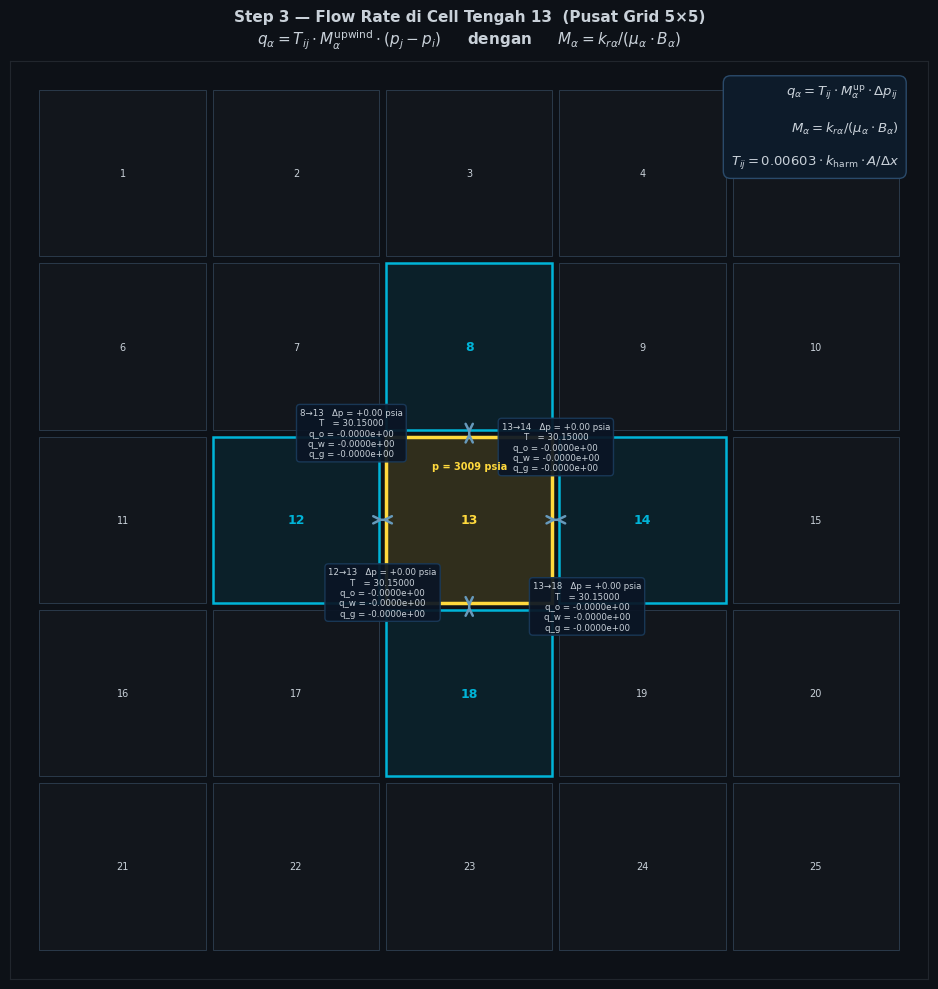

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dt = rm.DT_INITIAL
state_n = rm.init_state(grid['cells'])
state_k = {
    'p': [max(14.7, pressure - 2.0) for pressure in state_n['p']],
    'sw': list(state_n['sw']),
    'sg': list(state_n['sg']),
}

df_state_n = state_to_df(state_n, 'n')
df_state_k = state_to_df(state_k, 'k')
df_props_k = evaluate_state(grid, state_k)

# Mobility M = kr / (mu * B)
df_props_k['mobility_oil']   = df_props_k['kro'] / (df_props_k['mu_o'] * df_props_k['bo']).clip(lower=1e-14)
df_props_k['mobility_water'] = df_props_k['krw'] / (df_props_k['mu_w'] * df_props_k['bw']).clip(lower=1e-14)
df_props_k['mobility_gas']   = df_props_k['krg'] / (df_props_k['mu_g'] * df_props_k['bg']).clip(lower=1e-14)

net_flux      = rm.compute_net_flux(grid, state_k)
accumulation  = rm.compute_accumulation(grid, state_n, state_k, dt)
residual      = rm.compute_residual(net_flux, accumulation)
residual_norm = rm.residual_norm(residual, net_flux, accumulation)

def _acc_gas_decomp(grid, state_n, state_k, dt):
    dt = max(dt, 1e-14)
    rows = []
    for i, cell in enumerate(grid['cells']):
        pn, pk = state_n['p'][i], state_k['p'][i]
        sg_n = rm.clamp(state_n['sg'][i], 0.0, 1.0); sg_k = rm.clamp(state_k['sg'][i], 0.0, 1.0)
        sw_n = rm.clamp(state_n['sw'][i], 0.0, 1.0); sw_k = rm.clamp(state_k['sw'][i], 0.0, 1.0)
        so_n = rm.clamp(1.0 - sw_n - sg_n, 0.0, 1.0); so_k = rm.clamp(1.0 - sw_k - sg_k, 0.0, 1.0)
        pv_n = rm.pore_volume(cell, pn); pv_k = rm.pore_volume(cell, pk)
        bg_n = rm.interp(rm.PVT_BG, pn); bg_k = rm.interp(rm.PVT_BG, pk)
        bo_n = rm.interp(rm.PVT_BO, pn); bo_k = rm.interp(rm.PVT_BO, pk)
        rso_n = rso_k = 0.0
        free_k = rm.safe_div(pv_k * sg_k, bg_k); sol_k = rso_k * rm.safe_div(pv_k * so_k, bo_k)
        free_n = rm.safe_div(pv_n * sg_n, bg_n); sol_n = rso_n * rm.safe_div(pv_n * so_n, bo_n)
        rows.append({'cell': i + 1,
                     'acc_gas_free':     (free_k - free_n) / dt,
                     'acc_gas_solution': (sol_k  - sol_n)  / dt,
                     'acc_gas_total':    (free_k + sol_k - free_n - sol_n) / dt})
    return pd.DataFrame(rows)

df_acc_gas_decomp = _acc_gas_decomp(grid, state_n, state_k, dt)

df_conn_flux = pd.concat([
    df_connections[['connection', 'from_cell', 'to_cell', 'dir', 'T']].reset_index(drop=True),
    pd.DataFrame(net_flux['conn']).rename(columns={
        'oil': 'flux_oil', 'water': 'flux_water', 'gas': 'flux_gas',
        'phi_o': 'potential_oil', 'phi_w': 'potential_water', 'phi_g': 'potential_gas',
    })
], axis=1)

df_net_flux = pd.DataFrame({
    'cell': np.arange(1, len(net_flux['oil']) + 1),
    'net_flux_oil':   net_flux['oil'],
    'net_flux_water': net_flux['water'],
    'net_flux_gas':   net_flux['gas'],
})

df_accumulation = pd.DataFrame({
    'cell':      np.arange(1, len(accumulation['oil']) + 1),
    'acc_oil':   accumulation['oil'], 'acc_water': accumulation['water'],
    'acc_gas':   accumulation['gas'], 'acc_total': accumulation['total'],
})

df_residual = pd.DataFrame({
    'cell':           np.arange(1, len(residual['oil']) + 1),
    'residual_oil':   residual['oil'],   'residual_water': residual['water'],
    'residual_gas':   residual['gas'],   'residual_total': residual['total'],
})

df_residual_summary = pd.DataFrame([{
    'residual_norm':          residual_norm,
    'max_abs_residual_oil':   np.max(np.abs(df_residual['residual_oil'])),
    'max_abs_residual_water': np.max(np.abs(df_residual['residual_water'])),
    'max_abs_residual_gas':   np.max(np.abs(df_residual['residual_gas'])),
}])

print("=== State Awal (n) ===");           display(df_state_n.head())
print("\n=== State Tebakan Newton k ==="); display(df_state_k.head())
print("\n=== Properti Sel — Mobility M = kr/(mu*B) ===")
display(df_props_k[['cell','pressure_psia','so','sw','sg',
                     'kro','krw','krg','mu_o','mu_w','mu_g','bo','bw','bg',
                     'lam_o','lam_w','lam_g','mobility_oil','mobility_water','mobility_gas']].head())
print("\n=== Flux Per Koneksi (12 pertama) ==="); display(df_conn_flux.head(12))
print("\n=== Net Flux Per Sel ===");  display(df_net_flux.head())
print("\n=== Akumulasi Per Sel ==="); display(df_accumulation.head())
print("\n=== Dekomposisi Akumulasi Gas (free + solution) ==="); display(df_acc_gas_decomp.head())
print("\n=== Residual Per Sel ===");   display(df_residual.head())
print("\n=== Ringkasan Residual ==="); display(df_residual_summary)

# ============================================================
# Visualisasi: Flow Rate di Cell Tengah 13 (pusat grid 5x5)
#   q_alpha = T_ij * M_alpha_upwind * (pj - pi)
# ============================================================
CENTER = 13   # cell 13 = i=2, j=2 (0-indexed) → pusat grid 5x5

# Posisi plot: x = i_index, y = -j_index (j=0 di atas)
_pos  = {int(r['cell']): (int(r['i_index']), -int(r['j_index'])) for _, r in df_cells.iterrows()}
_cx0, _cy0 = _pos[CENTER]

_mask_c  = (df_conn_flux['from_cell'] == CENTER) | (df_conn_flux['to_cell'] == CENTER)
_c_conns = df_conn_flux[_mask_c].copy().reset_index(drop=True)
_nbr_set = set()
for _, _r in _c_conns.iterrows():
    _nbr_set.add(int(_r['to_cell']) if int(_r['from_cell']) == CENTER else int(_r['from_cell']))

BG, TC, GC = '#0d1117', '#c9d1d9', '#21262d'
C_CTR, C_NBR = '#ffd93d', '#00b4d8'

fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
for sp in ax.spines.values(): sp.set_color(GC)

# Gambar semua cell
for c, (cx, cy) in _pos.items():
    _is_key = c == CENTER or c in _nbr_set
    _fc = '#ffd93d25' if c == CENTER else ('#00b4d818' if c in _nbr_set else '#ffffff06')
    _ec = C_CTR if c == CENTER else (C_NBR if c in _nbr_set else '#2a3a4a')
    _lw = 2.5 if c == CENTER else (1.8 if c in _nbr_set else 0.7)
    ax.add_patch(mpatches.Rectangle((cx-0.48, cy-0.48), 0.96, 0.96,
                                     facecolor=_fc, edgecolor=_ec, lw=_lw, zorder=2))
    ax.text(cx, cy, str(c), ha='center', va='center',
            fontsize=9 if _is_key else 7, fontweight='bold' if _is_key else 'normal',
            color=C_CTR if c == CENTER else (C_NBR if c in _nbr_set else TC), zorder=3)

ax.text(_cx0, _cy0 + 0.31, f'p = {state_k["p"][CENTER-1]:.0f} psia',
        ha='center', va='center', fontsize=7, color=C_CTR, fontweight='bold', zorder=6)

# Perpendicular label offsets to avoid overlapping adjacent cells
_OFF = {(0, 1): (-0.68, 0), (0, -1): (0.68, 0), (1, 0): (0, 0.42), (-1, 0): (0, -0.42)}

for _, _row in _c_conns.iterrows():
    _fc2, _tc2 = int(_row['from_cell']), int(_row['to_cell'])
    _nbr = _tc2 if _fc2 == CENTER else _fc2
    _x1, _y1 = _pos[_nbr]
    _ddx, _ddy = int(np.sign(_x1 - _cx0)), int(np.sign(_y1 - _cy0))

    # Double-headed arrow between cell centers
    ax.annotate('',
        xy=(_x1 - _ddx*0.52, _y1 - _ddy*0.52),
        xytext=(_cx0 + _ddx*0.52, _cy0 + _ddy*0.52),
        arrowprops=dict(arrowstyle='<->', color='#6699bb', lw=1.8, mutation_scale=13), zorder=4)

    _mx, _my = (_cx0 + _x1) / 2, (_cy0 + _y1) / 2
    _ox, _oy = _OFF.get((_ddx, _ddy), (0, 0))

    _q_o = float(_row['flux_oil']); _q_w = float(_row['flux_water'])
    _q_g = float(_row['flux_gas']); _T   = float(_row['T'])
    _phi = float(_row['potential_oil'])

    _lbl = (f'{_fc2}→{_tc2}   Δp = {_phi:+.2f} psia\n'
            f'T   = {_T:.5f}\n'
            f'q_o = {_q_o:+.4e}\n'
            f'q_w = {_q_w:+.4e}\n'
            f'q_g = {_q_g:+.4e}')
    ax.text(_mx + _ox, _my + _oy, _lbl, ha='center', va='center',
            fontsize=6.2, color=TC, zorder=5,
            bbox=dict(facecolor='#0a1525', edgecolor='#1a3a5a',
                     boxstyle='round,pad=0.4', alpha=0.93))

ax.text(rm.NX - 0.52, 0.52,
        r'$q_\alpha = T_{ij} \cdot M_\alpha^{\mathrm{up}} \cdot \Delta p_{ij}$' + '\n\n'
        r'$M_\alpha = k_{r\alpha}/(\mu_\alpha \cdot B_\alpha)$' + '\n\n'
        r'$T_{ij} = 0.00603 \cdot k_{\mathrm{harm}} \cdot A / \Delta x$',
        ha='right', va='top', fontsize=9.5, color=TC,
        bbox=dict(facecolor='#0d1b2a', edgecolor='#2a4a6a', boxstyle='round,pad=0.55'), zorder=6)

ax.set_xlim(-0.65, rm.NX - 0.35); ax.set_ylim(-(rm.NY - 0.35), 0.65)
ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(
    f'Step 3 — Flow Rate di Cell Tengah {CENTER}  (Pusat Grid {rm.NX}×{rm.NY})\n'
    r'$q_\alpha = T_{ij} \cdot M_\alpha^{\mathrm{upwind}} \cdot (p_j - p_i)$'
    r'     dengan     $M_\alpha = k_{r\alpha}/(\mu_\alpha \cdot B_\alpha)$',
    color=TC, fontsize=11, fontweight='bold', pad=12)
plt.tight_layout(); plt.show()


## Step 4 - Jacobian of Residual Function

Tahap ini menyusun **Jacobian** — matriks turunan parsial residual terhadap semua unknown. Jacobian inilah yang membuat Newton-Raphson bisa menemukan arah koreksi yang tepat. Sesuai §6 dan §7 `docs/rumuspenting.md`.

---

### Kenapa Perlu Jacobian?

Newton-Raphson mencari akar `R(x) = 0` secara iteratif:

$$J \cdot \delta x = -R$$

di mana `J` adalah Jacobian (`∂R/∂x`), `δx` adalah koreksi yang dicari, dan `R` adalah residual saat ini.

Untuk N cell dengan 3 unknown (`p`, `Sw`, `Sg`) per cell → Jacobian berukuran **3N × 3N**.

---

### Struktur Blok Jacobian

Jacobian disusun dalam blok 3×3 per pasangan cell (i, j):

$$J_{ij} = \begin{bmatrix} \partial R_o^i/\partial p^j & \partial R_o^i/\partial S_w^j & \partial R_o^i/\partial S_g^j \\ \partial R_w^i/\partial p^j & \partial R_w^i/\partial S_w^j & \partial R_w^i/\partial S_g^j \\ \partial R_g^i/\partial p^j & \partial R_g^i/\partial S_w^j & \partial R_g^i/\partial S_g^j \end{bmatrix}$$

- **Blok diagonal** `J_ii`: pengaruh unknown cell i sendiri terhadap residualnya (terbesar)
- **Blok off-diagonal** `J_ij`: pengaruh unknown cell j terhadap residual cell i (ada hanya jika terhubung)

---

### 9 Turunan Parsial via Finite Difference

Jacobian dihitung **numerik** dengan perturbasi kecil. Ada 3 kolom perturbasi × 3 baris residual = 9 elemen per cell.

**Aturan penting:** Saat `Sw` atau `Sg` diperturb, `So` harus ikut diperbarui karena constraint `So = 1 - Sw - Sg`:

```
Perturb p  → So* = So              (tekanan tidak ubah saturasi)
Perturb Sw → So* = 1 - (Sw+ΔSw) - Sg  = So - ΔSw
Perturb Sg → So* = 1 - Sw - (Sg+ΔSg)  = So - ΔSg
```

| Kolom perturb | Yang berubah | Efek utama |
|---------------|-------------|------------|
| **∂/∂p** | Bo, Bw, Bg, μo, μw, μg, Rso dari tabel PVT | Semua mobility dan akumulasi berubah |
| **∂/∂Sw** | kro(So↓), krw(Sw↑) — So turun karena Sw naik | Flux minyak turun, flux air naik |
| **∂/∂Sg** | kro(So↓), krg(Sg↑) — So turun karena Sg naik | Flux minyak turun, flux gas naik |

---

### Ringkasan 9 Elemen Jacobian Per Cell

| | ∂/∂p | ∂/∂Sw | ∂/∂Sg |
|--|------|--------|--------|
| **∂Ro** | Bo↓ & μo↓ → Mo berubah + akumulasi So/Bo berubah | kro↓ (So↓) | kro↓ (So↓) |
| **∂Rw** | Bw↓ & μw↓ → Mw berubah + akumulasi Sw/Bw berubah | krw↑ + akumulasi↑ → **elemen diagonal dominan** | krw sedikit berubah |
| **∂Rg** | Bg↓ & Rso berubah → **elemen terbesar** | Rso·So↓ (coupling tidak langsung) | krg↑ + Sg/Bg↑ **dan** Rso·So↓ → **paling kompleks** |

**∂Rg/∂Sg adalah elemen paling kompleks** karena 3 hal terjadi bersamaan:
1. `krg(Sg+ΔSg)` **naik** → gas makin mudah mengalir (positif)
2. Akumulasi `Sg/Bg` **naik** langsung (positif)
3. `Rso·So*/Bo` **turun** karena `So* = So - ΔSg` (negatif)

Tiga pengaruh berlawanan arah → alasan utama Jacobian dihitung numerik, bukan analitik.

---

### Layout Matriks (contoh 9 cell, 27×27)

```
         p[1]  p[2] ... p[9] | Sw[1] Sw[2] ... Sw[9] | Sg[1] Sg[2] ... Sg[9]
R_o[1] [  *     *           |   *     .          .   |   *     .          .  ]
R_o[2] [  *     *     *     |   .     *          .   |   .     *          .  ]
...
R_w[1] [  *     .           |   *     *          .   |   *     .          .  ]
...
R_g[1] [  *     .           |   *     .          .   |   *     *          .  ]
```

`*` = non-zero (ada koneksi), `.` = zero (tidak terhubung)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

jacobian = rm.assemble_jacobian(grid, state_n, state_k, dt)
n_cells  = len(grid['cells'])
J        = np.array(jacobian, dtype=float)
n        = 3 * n_cells

row_labels, col_labels = jacobian_labels(n_cells)
jacobian_df = pd.DataFrame(J, index=row_labels, columns=col_labels)

nnz  = int(np.count_nonzero(J))
J_nz = np.abs(J[J != 0])
df_jacobian_stats = pd.DataFrame([{
    'ukuran matriks': f'{n} x {n}',
    'n_cell': n_cells,
    'nnz (non-zero)': nnz,
    'density %': round(100 * nnz / n**2, 2),
    'max |J|': float(J_nz.max()) if len(J_nz) else 0.0,
    'min |J| (non-zero)': float(J_nz.min()) if len(J_nz) else 0.0,
}])
print("=== Statistik Jacobian ===")
display(df_jacobian_stats)

def diag_block(J, c0, N):
    r = [c0, N+c0, 2*N+c0]
    return pd.DataFrame(
        J[np.ix_(r, r)],
        index  =[f'dRo[{c0+1}]/d?', f'dRw[{c0+1}]/d?', f'dRg[{c0+1}]/d?'],
        columns=[f'?=p[{c0+1}]',    f'?=Sw[{c0+1}]',   f'?=Sg[{c0+1}]'],
    )

CENTER_CELL = 13   # pusat grid 5x5
print(f"\n=== Blok Diagonal 3x3 — Cell {CENTER_CELL} (pusat, self-coupling) ===")
display(diag_block(J, CENTER_CELL - 1, n_cells))

# ── Permutasi ke cell-major (unknown per cell: p,Sw,Sg | residual per cell: Ro,Rw,Rg) ─
# perm[k] = posisi di J-original untuk baris/kolom ke-k di J_cm
# urutan: Ro1,Rw1,Rg1 | Ro2,Rw2,Rg2 | ... (untuk baris)
#          p1,Sw1,Sg1  | p2,Sw2,Sg2  | ... (untuk kolom)
perm     = [alpha * n_cells + c for c in range(n_cells) for alpha in range(3)]
J_cm     = J[np.ix_(perm, perm)]
J_abs_cm = np.abs(J_cm)

conn_pairs_0 = list(zip(
    df_connections['from_cell'].astype(int) - 1,
    df_connections['to_cell'].astype(int) - 1,
))

BG, TC, GC = '#0d1117', '#c9d1d9', '#21262d'
C_DIAG = '#ffd93d'
C_CONN = '#06d6a0'
C_SEP  = '#ff4444'    # merah — separator antar cell

# ── Tick labels: setiap cell menampilkan 3 unknown (X) / 3 residual (Y) ─────
x_lbl = []
y_lbl = []
for c in range(n_cells):
    x_lbl += [f'p·{c+1}', f'Sw·{c+1}', f'Sg·{c+1}']
    y_lbl += [f'Ro·{c+1}', f'Rw·{c+1}', f'Rg·{c+1}']

# ─────────────────────────────────────────────────────────────────────────────
# Figure 1: Heatmap + Sparsity  (cell-major, X=unknown, Y=residual)
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax_h, ax_s) = plt.subplots(1, 2, figsize=(24, 10))
fig.patch.set_facecolor(BG)
for ax in (ax_h, ax_s):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_color(GC)
    ax.tick_params(colors=TC, labelsize=4.5)

# ── Heatmap (log|J|) ─────────────────────────────────────────────────────────
J_log  = np.where(J_abs_cm > 1e-30, np.log10(J_abs_cm), np.nan)
cmap_h = plt.cm.plasma.copy(); cmap_h.set_bad(BG)
vmin   = np.nanmin(J_log) if not np.all(np.isnan(J_log)) else -10
vmax   = np.nanmax(J_log) if not np.all(np.isnan(J_log)) else 10

im = ax_h.imshow(J_log, cmap=cmap_h, aspect='auto',
                 interpolation='nearest', vmin=vmin, vmax=vmax)

# Garis merah pemisah antar cell (setiap 3 baris/kolom)
for t in range(3, n, 3):
    ax_h.axhline(t - 0.5, color=C_SEP, lw=1.0, zorder=5, alpha=0.85)
    ax_h.axvline(t - 0.5, color=C_SEP, lw=1.0, zorder=5, alpha=0.85)

# Blok diagonal (self-coupling) — kuning
for c in range(n_cells):
    lw_r = 2.5 if (c + 1) == CENTER_CELL else 1.0
    ax_h.add_patch(mpatches.Rectangle(
        (3*c - 0.5, 3*c - 0.5), 3, 3,
        linewidth=lw_r, edgecolor=C_DIAG, facecolor='none', zorder=6))

# Off-diagonal (koneksi)
for (ci, cj) in conn_pairs_0:
    for (ry, cx) in [(ci, cj), (cj, ci)]:
        ax_h.add_patch(mpatches.Rectangle(
            (3*cx - 0.5, 3*ry - 0.5), 3, 3,
            linewidth=0.8, edgecolor=C_CONN, facecolor='none', zorder=4, alpha=0.7))

cbar = fig.colorbar(im, ax=ax_h, shrink=0.85, pad=0.02)
cbar.set_label('log10|J|', color=TC, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=TC, labelsize=8)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TC)
cbar.outline.set_edgecolor(GC)

ax_h.set_xticks(range(n))
ax_h.set_xticklabels(x_lbl, fontsize=4.2, color=TC, rotation=90, ha='center')
ax_h.set_yticks(range(n))
ax_h.set_yticklabels(y_lbl, fontsize=4.2, color=TC)

# Warnai label p (kolom 0 tiap block) lebih terang
for idx, lbl in enumerate(ax_h.get_xticklabels()):
    if idx % 3 == 0:
        lbl.set_color('#58a6ff')
        lbl.set_fontweight('bold')
for idx, lbl in enumerate(ax_h.get_yticklabels()):
    if idx % 3 == 0:
        lbl.set_color('#ff9944')
        lbl.set_fontweight('bold')

ax_h.set_xlabel('Unknown per cell  [ p | Sw | Sg ]', color=TC, fontsize=9)
ax_h.set_ylabel('Residual per cell  [ Ro | Rw | Rg ]', color=TC, fontsize=9)
ax_h.set_title(
    f'Jacobian {n}x{n} — Heatmap log|J|  (cell-major)\n'
    f'Garis merah = batas antar cell  |  Kuning = diagonal (self)  |  Hijau = koneksi',
    color=TC, fontsize=10, fontweight='bold', pad=8)

# ── Sparsity Pattern ──────────────────────────────────────────────────────────
J_bool = (J_abs_cm > 1e-30).astype(float)
ax_s.imshow(J_bool, cmap='Blues', aspect='auto',
            interpolation='nearest', vmin=0, vmax=1.5)

for t in range(3, n, 3):
    ax_s.axhline(t - 0.5, color=C_SEP, lw=1.0, zorder=5, alpha=0.85)
    ax_s.axvline(t - 0.5, color=C_SEP, lw=1.0, zorder=5, alpha=0.85)

fs_cell = 7 if n_cells <= 16 else 5.5
for c in range(n_cells):
    lw_r = 2.5 if (c + 1) == CENTER_CELL else 1.2
    ax_s.add_patch(mpatches.Rectangle(
        (3*c - 0.5, 3*c - 0.5), 3, 3,
        linewidth=lw_r, edgecolor=C_DIAG, facecolor='none', zorder=6))
    _clr = '#ff6b6b' if (c + 1) == CENTER_CELL else C_DIAG
    ax_s.text(3*c + 1, 3*c + 1, f'{c+1}',
              ha='center', va='center', fontsize=fs_cell,
              fontweight='bold', color=_clr, zorder=7)

seen_pairs = set()
for (ci, cj) in conn_pairs_0:
    key = (min(ci, cj), max(ci, cj))
    if key in seen_pairs: continue
    seen_pairs.add(key)
    for (ry, cx) in [(ci, cj), (cj, ci)]:
        ax_s.text(3*cx + 1, 3*ry + 1, 'x',
                  ha='center', va='center', fontsize=fs_cell,
                  color=C_CONN, fontweight='bold', zorder=7)

ax_s.set_xticks(range(n))
ax_s.set_xticklabels(x_lbl, fontsize=4.2, color=TC, rotation=90, ha='center')
ax_s.set_yticks(range(n))
ax_s.set_yticklabels(y_lbl, fontsize=4.2, color=TC)

for idx, lbl in enumerate(ax_s.get_xticklabels()):
    if idx % 3 == 0:
        lbl.set_color('#58a6ff')
        lbl.set_fontweight('bold')
for idx, lbl in enumerate(ax_s.get_yticklabels()):
    if idx % 3 == 0:
        lbl.set_color('#ff9944')
        lbl.set_fontweight('bold')

ax_s.set_xlabel('Unknown per cell  [ p | Sw | Sg ]', color=TC, fontsize=9)
ax_s.set_ylabel('Residual per cell  [ Ro | Rw | Rg ]', color=TC, fontsize=9)
ax_s.legend(handles=[
    mpatches.Patch(facecolor='#2171b5', label='Entry != 0'),
    mpatches.Patch(facecolor=BG,        label='Entry = 0'),
    mpatches.Patch(facecolor='none', edgecolor=C_DIAG, lw=1.5, label='Diagonal (self-coupling)'),
    mpatches.Patch(facecolor='none', edgecolor=C_CONN, lw=1.5, label='Off-diag (koneksi)'),
    mpatches.Patch(facecolor='none', edgecolor=C_SEP,  lw=1.5, label='Garis merah = batas cell'),
], fontsize=7.5, loc='upper right',
   facecolor='#0d1117', edgecolor=GC, labelcolor=TC)
ax_s.set_title(
    f'Sparsity Pattern {n}x{n}  (cell-major)\n'
    f'Angka = nomor cell  |  x hijau = koneksi  |  Merah tebal = cell {CENTER_CELL} (tengah)',
    color=TC, fontsize=10, fontweight='bold', pad=8)

fig.suptitle(
    f'Step 4 — Jacobian  {n_cells} cell x 3 fasa = {n}x{n}\n'
    f'Kolom (X) = unknown per cell: p | Sw | Sg   |   Baris (Y) = residual per cell: Ro | Rw | Rg\n'
    f'Garis merah = pemisah blok antar cell',
    color=TC, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 2: 9 Kemungkinan — Blok 3x3 Diagonal Cell 13 (pusat)
# J_ii = dR^(i)/dx^(i)  untuk cell itu sendiri
# ─────────────────────────────────────────────────────────────────────────────
c0      = CENTER_CELL - 1
_r_idx  = [3*c0, 3*c0+1, 3*c0+2]
J_block = J_cm[np.ix_(_r_idx, _r_idx)]

_ROW_LBL = [r'$\partial R_o$', r'$\partial R_w$', r'$\partial R_g$']
_COL_LBL = [r'$/\partial p$', r'$/\partial S_w$', r'$/\partial S_g$']
_DESCS   = [
    ['Bo, mu_o berubah\n-> Mo & akum So/Bo',   'kro turun (So turun)',       'kro turun (So turun)'],
    ['Bw, mu_w berubah\n-> Mw & akum Sw/Bw',   'krw naik + akum naik\n-> diagonal dominan', 'krw sedikit berubah'],
    ['Bg, Rso berubah\n-> elemen terbesar',      'Rso*So turun\n(coupling tdk langsung)',      'krg naik + Sg/Bg naik\n+ Rso*So turun\n-> paling kompleks'],
]

fig2, ax2 = plt.subplots(figsize=(14, 7))
fig2.patch.set_facecolor(BG); ax2.set_facecolor(BG)
for sp in ax2.spines.values(): sp.set_color(GC)
ax2.axis('off')

CW, CH, GAP = 4.0, 2.1, 0.25

for ri in range(3):
    for ci in range(3):
        val = J_block[ri, ci]
        x0  = ci * (CW + GAP)
        y0  = (2 - ri) * (CH + GAP)

        _is_diag = ri == ci
        _is_nz   = abs(val) > 1e-30
        _fc = '#ffd93d12' if _is_diag else ('#ff6b6b08' if _is_nz else '#ffffff04')
        _ec = C_DIAG if _is_diag else ('#3a5a8a' if _is_nz else '#2a3a4a')
        _lw = 2.2 if _is_diag else (0.9 if _is_nz else 0.4)

        ax2.add_patch(mpatches.FancyBboxPatch(
            (x0, y0), CW, CH, boxstyle='round,pad=0.1',
            facecolor=_fc, edgecolor=_ec, lw=_lw, zorder=2))

        _vs = f'{val:.5e}' if _is_nz else '0'
        _vc = C_DIAG if _is_diag else (TC if _is_nz else '#444444')
        ax2.text(x0 + CW/2, y0 + CH*0.70, _vs,
                 ha='center', va='center', fontsize=10, fontweight='bold',
                 color=_vc, family='monospace', zorder=3)

        ax2.text(x0 + CW/2, y0 + CH*0.28, _DESCS[ri][ci],
                 ha='center', va='center', fontsize=7.5, color='#aaaaaa',
                 linespacing=1.4, zorder=3)

for ri, rl in enumerate(_ROW_LBL):
    y0 = (2 - ri) * (CH + GAP) + CH/2
    ax2.text(-0.25, y0, rl, ha='right', va='center', fontsize=12,
             color='#ff6b6b', fontweight='bold')

for ci, cl in enumerate(_COL_LBL):
    x0 = ci * (CW + GAP) + CW/2
    ax2.text(x0, 3*(CH + GAP) + 0.1, cl, ha='center', va='bottom',
             fontsize=12, color='#06d6a0', fontweight='bold')

ax2.set_xlim(-1.9, 3*(CW + GAP) + 0.3)
ax2.set_ylim(-0.4, 3*(CH + GAP) + 0.75)
ax2.set_title(
    f'9 Kemungkinan Turunan Parsial — Blok Diagonal Cell {CENTER_CELL} (Pusat Grid {n_cells})\n'
    r'$J_{ii} = \partial R^{(i)} / \partial x^{(i)}$'
    r'   —   dR/dp  |  dR/dSw  |  dR/dSg',
    color=TC, fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

print("\n=== Potongan Jacobian — 3 cell pertama x 3 cell pertama (9x9) ===")
display(jacobian_df.iloc[:9, :9])


## Step 5 - Update Iteration

Setelah Jacobian `J` dan residual `R` tersedia, sistem linear **`J · δx = -R`** diselesaikan dengan eliminasi Gauss. Hasilnya adalah vektor koreksi `δx` yang dipakai untuk memperbarui semua primary variables. Sesuai §7 dan §8 `docs/rumuspenting.md`.

---

### Sistem Linear yang Diselesaikan

$$J \cdot \delta x = -R$$

$$\begin{bmatrix} J_{11} & J_{12} & \cdots \\ J_{21} & J_{22} & \cdots \\ \vdots & & \ddots \end{bmatrix} \begin{bmatrix} \delta p_1 \\ \delta S_{w,1} \\ \delta S_{g,1} \\ \vdots \end{bmatrix} = - \begin{bmatrix} R_{o,1} \\ R_{w,1} \\ R_{g,1} \\ \vdots \end{bmatrix}$$

Solver yang dipakai: **Gaussian elimination dengan partial pivoting** (dense matrix). Untuk grid besar lebih efisien memakai solver sparse, tapi eliminasi Gauss cukup untuk grid kecil ini.

---

### Update Primary Variables

Setelah `δx` ditemukan, update dilakukan per cell:

$$p^{k+1} = p^k + \delta p$$
$$S_w^{k+1} = \text{clamp}(S_w^k + \delta S_w,\ 0,\ 1)$$
$$S_g^{k+1} = \text{clamp}(S_g^k + \delta S_g,\ 0,\ 1)$$
$$S_o^{k+1} = 1 - S_w^{k+1} - S_g^{k+1} \quad \text{(constraint, bukan unknown)}$$

**Kenapa saturasi di-clamp ke [0, 1]?** Solver linear tidak mengenal batas fisik. Saturasi negatif atau > 1 adalah tidak fisik dan akan menyebabkan `kr` interpolasi di luar tabel. Clamp mencegah hal ini.

---

### Update PVT Setelah Koreksi

Setelah primary variables diperbarui, **semua properti PVT dan relative perm harus dihitung ulang** sebelum iterasi Newton berikutnya:

| Properti | Diperbarui berdasarkan | Keterangan |
|----------|----------------------|-----------|
| `Bo, Bw, Bg` | `p^{k+1}` | Interpolasi tabel PVT |
| `μo, μw, μg` | `p^{k+1}` | Interpolasi tabel PVT |
| `Rso` | `p^{k+1}` | Solution GOR, turun saat p turun |
| `kro` | `So^{k+1}` | Interpolasi tabel kr |
| `krw` | `Sw^{k+1}` | Interpolasi tabel kr |
| `krg` | `Sg^{k+1}` | Interpolasi tabel kr |
| `Mo, Mw, Mg` | `kr / (μ·B)` dengan nilai baru | Mobility diperbarui |

Properti yang di-update inilah yang dipakai di **Step 3 iterasi berikutnya** untuk menghitung residual baru.

---

### Apa yang Dibandingkan: `k` vs `k+1`

Notebook menampilkan perbandingan state iterasi k dan k+1 untuk melihat seberapa besar koreksi. Koreksi yang mengecil dari iterasi ke iterasi menandakan Newton sedang konvergen.

=== Vektor Koreksi δx (head) ===


,cell,delta_p,delta_sw,delta_sg
0,1,2,0,0
1,2,2,0,0
2,3,2,0,0
3,4,2,0,0
4,5,2,0,0



=== Perbandingan State k → k+1 (head) ===


,cell,pressure_psia_k,pressure_psia_k1,dp,sw_k,sw_k1,dSw,sg_k,sg_k1,dSg
0,1,"3,009","3,010",1,0,0,0,0,0,0
1,2,"3,009","3,010",1,0,0,0,0,0,0
2,3,"3,009","3,010",1,0,0,0,0,0,0
3,4,"3,009","3,010",1,0,0,0,0,0,0
4,5,"3,009","3,010",1,0,0,0,0,0,0


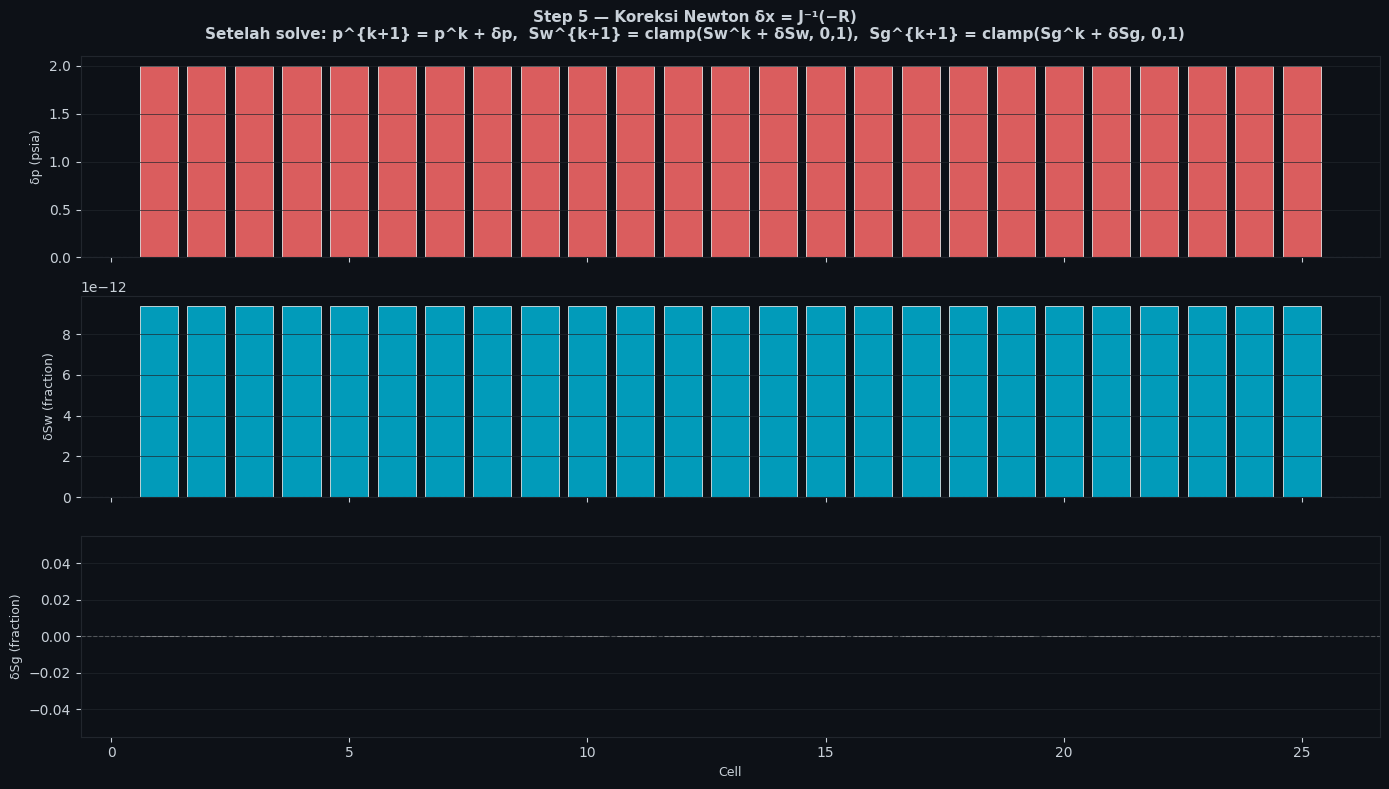


=== Statistik Koreksi ===


,max |δp|,max |δp|/|p|,max |δSw|,max |δSg|,param_change,param_tol,param_ok
0,2,0,0,0,0,0,False


In [39]:
import matplotlib.pyplot as plt

# ── Solve J · δx = −R ─────────────────────────────────────────────────────────
rhs    = [-v for v in residual['vec']]
delta  = rm.gauss_solve(jacobian, rhs)
state_k1 = rm.apply_correction(state_k, delta)

# ── Vektor koreksi δx ─────────────────────────────────────────────────────────
df_delta = pd.DataFrame({
    'cell':     np.arange(1, n_cells + 1),
    'delta_p':  delta[:n_cells],
    'delta_sw': delta[n_cells : 2*n_cells],
    'delta_sg': delta[2*n_cells :],
})

# ── Perbandingan state k vs k+1 ───────────────────────────────────────────────
df_state_k1 = state_to_df(state_k1, 'k+1')
df_compare  = df_state_k[['cell','pressure_psia','sw','sg','so']].merge(
    df_state_k1[['cell','pressure_psia','sw','sg','so']],
    on='cell', suffixes=('_k','_k1'),
)
df_compare['dp']  = df_compare['pressure_psia_k1'] - df_compare['pressure_psia_k']
df_compare['dSw'] = df_compare['sw_k1'] - df_compare['sw_k']
df_compare['dSg'] = df_compare['sg_k1'] - df_compare['sg_k']
df_compare['dSo'] = df_compare['so_k1'] - df_compare['so_k']

print("=== Vektor Koreksi δx (head) ===")
display(df_delta.head())
print("\n=== Perbandingan State k → k+1 (head) ===")
display(df_compare[['cell','pressure_psia_k','pressure_psia_k1','dp',
                     'sw_k','sw_k1','dSw','sg_k','sg_k1','dSg']].head())

# ── Visualisasi: koreksi per cell ─────────────────────────────────────────────
BG, TEXT_C, GRID_C = '#0d1117', '#c9d1d9', '#21262d'
COLORS = {'δp': '#ff6b6b', 'δSw': '#00b4d8', 'δSg': '#06d6a0', 'δSo': '#ffd93d'}

cells_x = df_delta['cell'].to_numpy()
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor(BG)

data_panels = [
    ('delta_p',  'δp (psia)',      COLORS['δp']),
    ('delta_sw', 'δSw (fraction)', COLORS['δSw']),
    ('delta_sg', 'δSg (fraction)', COLORS['δSg']),
]
for ax, (col, ylabel, color) in zip(axes, data_panels):
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_color(GRID_C)
    ax.tick_params(colors=TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    vals = df_delta[col].to_numpy()
    ax.bar(cells_x, vals, color=color, alpha=0.85, edgecolor='#ffffff18', lw=0.6)
    ax.axhline(0, color='#ffffff40', lw=0.8, ls='--')
    ax.set_ylabel(ylabel, color=TEXT_C, fontsize=9)
    ax.grid(True, axis='y', color=GRID_C, alpha=0.8, lw=0.6)
    ax.title.set_color(TEXT_C)

axes[-1].set_xlabel('Cell', color=TEXT_C, fontsize=9)
axes[-1].tick_params(axis='x', colors=TEXT_C)

fig.suptitle('Step 5 — Koreksi Newton δx = J⁻¹(−R)\n'
             'Setelah solve: p^{k+1} = p^k + δp,  Sw^{k+1} = clamp(Sw^k + δSw, 0,1),  Sg^{k+1} = clamp(Sg^k + δSg, 0,1)',
             color=TEXT_C, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Statistik koreksi ─────────────────────────────────────────────────────────
df_delta_stats = pd.DataFrame([{
    'max |δp|':       df_delta['delta_p'].abs().max(),
    'max |δp|/|p|':   (df_delta['delta_p'].abs() /
                       df_state_k['pressure_psia'].abs().clip(lower=1.0)).max(),
    'max |δSw|':      df_delta['delta_sw'].abs().max(),
    'max |δSg|':      df_delta['delta_sg'].abs().max(),
    'param_change':   max(
                        (df_delta['delta_p'].abs() /
                         df_state_k['pressure_psia'].abs().clip(lower=1.0)).max(),
                        df_delta['delta_sw'].abs().max(),
                        df_delta['delta_sg'].abs().max(),
                      ),
    'param_tol':      rm.PARAM_TOL,
    'param_ok':       max(
                        (df_delta['delta_p'].abs() /
                         df_state_k['pressure_psia'].abs().clip(lower=1.0)).max(),
                        df_delta['delta_sw'].abs().max(),
                        df_delta['delta_sg'].abs().max(),
                      ) <= rm.PARAM_TOL,
}])
print("\n=== Statistik Koreksi ===")
display(df_delta_stats)

## Step 6 - Check Residual and Numerical Constraints

Setelah update `k → k+1`, residual dihitung ulang dan dibandingkan terhadap dua kriteria konvergensi. Jika keduanya terpenuhi, timestep diterima dan simulasi maju ke waktu berikutnya. Jika tidak, loop kembali ke Step 3. Sesuai §9 dan §10 `docs/rumuspenting.md`.

---

### Dua Kriteria Konvergensi (Dual Convergence)

Konvergensi Newton baru dinyatakan tercapai jika **kedua** kriteria ini terpenuhi bersamaan:

#### Kriteria 1 — Residual Norm

$$\frac{\max_{i,\alpha} |R_{\alpha,i}^k|}{\text{scale}} \leq \varepsilon_R$$

| Simbol | Keterangan |
|--------|-----------|
| `|R_α,i|` | Nilai absolut residual fasa α di cell i |
| `scale` | Normalisasi = max(max_flux, max_accumulation, 1.0) |
| `ε_R` | Toleransi residual (parameter solver, biasanya 1e-4 s/d 1e-3) |

Normalisasi `scale` penting: residual dalam satuan RB/day bisa sangat besar atau kecil tergantung ukuran cell dan timestep — tanpa normalisasi, toleransi absolut tidak bermakna fisis.

#### Kriteria 2 — Parameter Change

$$\max\left(\frac{|\delta p|}{|p|},\ |\delta S_w|,\ |\delta S_g|\right) \leq \varepsilon_{param}$$

| Cek | Makna | Kenapa relatif/absolut berbeda |
|-----|-------|-------------------------------|
| `|δp| / |p|` | Perubahan tekanan **relatif** | Tekanan bisa ribuan psia — 1 psia koreksi di 3000 psia sangat kecil |
| `|δSw|` | Perubahan saturasi air **absolut** | Saturasi selalu di [0,1] — absolut sudah bermakna |
| `|δSg|` | Perubahan saturasi gas **absolut** | Sama seperti Sw |

---

### Kontrol Timestep Adaptif

| Kondisi | Aksi | Faktor |
|---------|------|--------|
| Newton konvergen | Naikkan dt | `dt_next = dt × growth_factor` (> 1) |
| Newton gagal, masih bisa retry | Turunkan dt dan ulangi | `dt_retry = dt × shrink_factor` (< 1) |
| Newton gagal, dt sudah minimum | Abort simulasi | — |

**Growth factor** memungkinkan timestep membesar secara otomatis saat kondisi reservoir "mudah" (gradien kecil), menghemat waktu komputasi. **Shrink factor** menjaga stabilitas saat perubahan besar terjadi (misalnya saat front saturasi melewati suatu cell).

---

### Alur Keputusan Per Timestep

```
hitung R(state_k+1)
        │
        ▼
  Kriteria 1 terpenuhi? ──No──►  hitung J, solve J·δx=-R
  (norm < ε_R)                    update state k+1
        │ Yes                     balik ke atas
        │
  Kriteria 2 terpenuhi? ──No──►  hitung J, solve J·δx=-R
  (param < ε_p)                   update state k+1
        │ Yes                     balik ke atas
        │
        ▼
   KONVERGEN → simpan state, dt *= growth_factor
```

Jika iterasi Newton habis (max_newton_iter) tanpa konvergen → `dt *= shrink_factor` → coba ulang dari state awal timestep.

=== Kriteria Konvergensi Iterasi Ini ===


,norm_k (sebelum),norm_k+1 (sesudah),resid_ok,max_dp_rel,max_dSw,max_dSg,param_change,param_ok,dual_converged
0,1,1,False,0,0,0,0,False,False



  -- Newton Loop  (dt=1.0000 d, target t=1.0000 d) --
    Iter  1: norm=1.0000e+00  crit1=False  crit2=False
    Iter  2: norm=1.0000e+00  crit1=False  crit2=False
    Iter  3: norm=1.0000e+00  crit1=False  crit2=False
    Iter  4: norm=1.0000e+00  crit1=False  crit2=True  (param OK, norm belum)
    Iter  5: norm=5.9364e-01  crit1=False  crit2=True  (param OK, norm belum)
    Iter  6: norm=1.7808e-01  crit1=False  crit2=True  (param OK, norm belum)
    Iter  7: norm=5.3421e-02  crit1=False  crit2=True  (param OK, norm belum)
    Iter  8: norm=1.6025e-02  crit1=True  crit2=True  <- KONVERGEN
    -> Konvergen dalam 8 iterasi Newton

=== Ringkasan Timestep ===


,timestep_day,converged,newton_iterations,final_norm,resid_tol,param_tol,next_action
0,1,True,8,0,0,0,advance → t+dt



=== State Diterima (setelah konvergen) ===


,state,cell,pressure_psia,sw,sg,so
0,accepted_step,1,"3,011",0,0,1
1,accepted_step,2,"3,011",0,0,1
2,accepted_step,3,"3,011",0,0,1
3,accepted_step,4,"3,011",0,0,1
4,accepted_step,5,"3,011",0,0,1


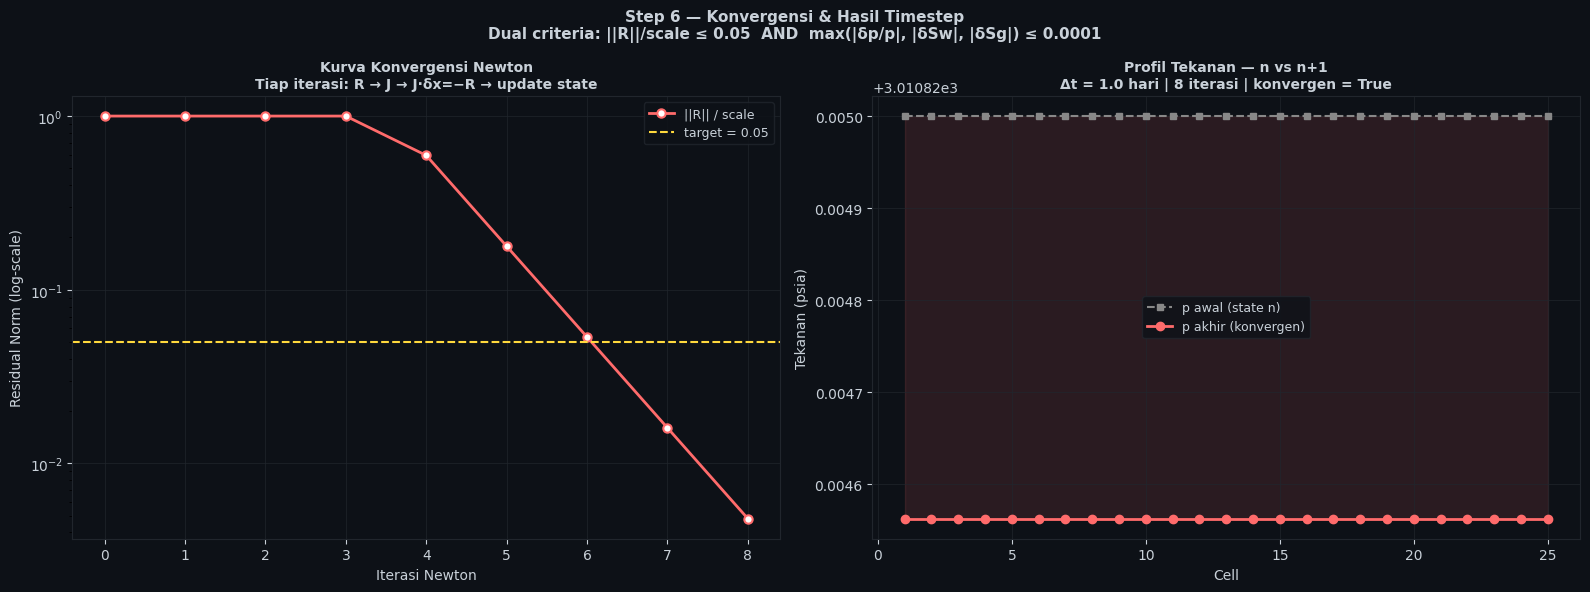

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Residual setelah update k → k+1 ──────────────────────────────────────────
net_flux_k1     = rm.compute_net_flux(grid, state_k1)
accumulation_k1 = rm.compute_accumulation(grid, state_n, state_k1, dt)
residual_k1     = rm.compute_residual(net_flux_k1, accumulation_k1)
residual_norm_k1 = rm.residual_norm(residual_k1, net_flux_k1, accumulation_k1)

max_dp_rel = max(
    abs(state_k1['p'][i] - state_k['p'][i]) / max(abs(state_k['p'][i]), 1.0)
    for i in range(n_cells)
)
max_dsw = max(abs(state_k1['sw'][i] - state_k['sw'][i]) for i in range(n_cells))
max_dsg = max(abs(state_k1['sg'][i] - state_k['sg'][i]) for i in range(n_cells))
param_change = max(max_dp_rel, max_dsw, max_dsg)

df_convergence = pd.DataFrame([{
    'norm_k (sebelum)':   residual_norm,
    'norm_k+1 (sesudah)': residual_norm_k1,
    'resid_ok':           residual_norm_k1 <= rm.RESID_TOL,
    'max_dp_rel':         max_dp_rel,
    'max_dSw':            max_dsw,
    'max_dSg':            max_dsg,
    'param_change':       param_change,
    'param_ok':           param_change <= rm.PARAM_TOL,
    'dual_converged':     residual_norm_k1 <= rm.RESID_TOL and param_change <= rm.PARAM_TOL,
}])
print("=== Kriteria Konvergensi Iterasi Ini ===")
display(df_convergence)

# ── Loop Newton mini — kumpulkan history norma tiap iterasi ──────────────────
norm_history: list[float] = []   # norm di awal tiap iterasi (sebelum update)

_state_iter = dict(state_k)
for _iter in range(rm.MAX_NEWTON_ITER):
    _nf   = rm.compute_net_flux(grid, _state_iter)
    _acc  = rm.compute_accumulation(grid, state_n, _state_iter, dt)
    _res  = rm.compute_residual(_nf, _acc)
    _norm = rm.residual_norm(_res, _nf, _acc)
    norm_history.append(_norm)

    _rhs  = [-v for v in _res['vec']]
    _J    = rm.assemble_jacobian(grid, state_n, _state_iter, dt)
    _delt = rm.gauss_solve(_J, _rhs)
    _state_iter = rm.apply_correction(_state_iter, _delt)

    _dp_rel = max(abs(_delt[i]) / max(abs(_state_iter['p'][i]), 1.0) for i in range(n_cells))
    _dsw    = max(abs(_delt[n_cells + i]) for i in range(n_cells))
    _dsg    = max(abs(_delt[2*n_cells + i]) for i in range(n_cells))
    if _norm <= rm.RESID_TOL and max(_dp_rel, _dsw, _dsg) <= rm.PARAM_TOL:
        break

# Append norm final (setelah update terakhir)
_nf_final  = rm.compute_net_flux(grid, _state_iter)
_acc_final = rm.compute_accumulation(grid, state_n, _state_iter, dt)
_res_final = rm.compute_residual(_nf_final, _acc_final)
norm_history.append(rm.residual_norm(_res_final, _nf_final, _acc_final))

# Jalankan via run_timestep untuk state final resmi
state_step_1, converged, final_norm, used_iter = rm.run_timestep(grid, state_n, dt, dt, 1)
df_state_step_1 = state_to_df(state_step_1, 'accepted_step')

df_step_summary = pd.DataFrame([{
    'timestep_day':      dt,
    'converged':         converged,
    'newton_iterations': used_iter,
    'final_norm':        final_norm,
    'resid_tol':         rm.RESID_TOL,
    'param_tol':         rm.PARAM_TOL,
    'next_action':       'advance → t+dt' if converged else 'cutback → dt×shrink',
}])
print("\n=== Ringkasan Timestep ===")
display(df_step_summary)
print("\n=== State Diterima (setelah konvergen) ===")
display(df_state_step_1.head())

# ── Visualisasi: kurva konvergensi + profil tekanan ───────────────────────────
BG, TEXT_C, GRID_C = '#0d1117', '#c9d1d9', '#21262d'
C_NORM, C_TOL = '#ff6b6b', '#ffd93d'

fig, (ax_conv, ax_state) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
for ax in (ax_conv, ax_state):
    ax.set_facecolor(BG)
    for sp in ax.spines.values():
        sp.set_color(GRID_C)
    ax.tick_params(colors=TEXT_C)

# ── Kiri: Kurva konvergensi ──────────────────────────────────────────────────
iters_x = np.arange(len(norm_history))
ax_conv.semilogy(iters_x, norm_history, 'o-', color=C_NORM, lw=2, ms=6,
                 markerfacecolor='white', markeredgewidth=1.5, label='||R|| / scale')
ax_conv.axhline(rm.RESID_TOL, color=C_TOL, lw=1.5, ls='--',
                label=f'target = {rm.RESID_TOL}')
ax_conv.set_xlabel('Iterasi Newton', color=TEXT_C, fontsize=10)
ax_conv.set_ylabel('Residual Norm (log-scale)', color=TEXT_C, fontsize=10)
ax_conv.set_title('Kurva Konvergensi Newton\n'
                  'Tiap iterasi: R → J → J·δx=−R → update state',
                  color=TEXT_C, fontsize=10, fontweight='bold')
ax_conv.legend(fontsize=9, facecolor='#0d1117', edgecolor=GRID_C, labelcolor=TEXT_C)
ax_conv.grid(True, color=GRID_C, alpha=0.8, lw=0.6)
ax_conv.yaxis.label.set_color(TEXT_C)
ax_conv.xaxis.label.set_color(TEXT_C)

# ── Kanan: Profil tekanan sebelum vs sesudah ─────────────────────────────────
cell_ids = df_state_step_1['cell'].to_numpy()
p_init   = df_state_n['pressure_psia'].to_numpy()
p_final  = df_state_step_1['pressure_psia'].to_numpy()

ax_state.plot(cell_ids, p_init,  's--', color='#888888', lw=1.5, ms=5,
              label='p awal (state n)')
ax_state.plot(cell_ids, p_final, 'o-',  color='#ff6b6b', lw=2,   ms=6,
              label='p akhir (konvergen)')
ax_state.fill_between(cell_ids, p_init, p_final, alpha=0.12, color='#ff6b6b')
ax_state.set_xlabel('Cell', color=TEXT_C, fontsize=10)
ax_state.set_ylabel('Tekanan (psia)', color=TEXT_C, fontsize=10)
ax_state.set_title(f'Profil Tekanan — n vs n+1\n'
                   f'Δt = {dt} hari | {used_iter} iterasi | konvergen = {converged}',
                   color=TEXT_C, fontsize=10, fontweight='bold')
ax_state.legend(fontsize=9, facecolor='#0d1117', edgecolor=GRID_C, labelcolor=TEXT_C)
ax_state.grid(True, color=GRID_C, alpha=0.8, lw=0.6)
ax_state.yaxis.label.set_color(TEXT_C)
ax_state.xaxis.label.set_color(TEXT_C)

fig.suptitle(
    f'Step 6 — Konvergensi & Hasil Timestep\n'
    f'Dual criteria: ||R||/scale ≤ {rm.RESID_TOL}  AND  max(|δp/p|, |δSw|, |δSg|) ≤ {rm.PARAM_TOL}',
    color=TEXT_C, fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

## Step 7 — Final State: Semua Properti Per Cell

Setelah Newton converge, hitung dan tampilkan **semua properti PVT + saturasi** untuk setiap cell di grid `NX×NY`.

| Properti | Sumber | Keterangan |
|----------|--------|------------|
| `p (psia)` | state | Tekanan per cell |
| `So, Sw, Sg` | state | Saturasi 3 fasa |
| `Bo, Bw, Bg` | PVT table | Formation volume factor |
| `mu_o, mu_w, mu_g` | PVT table | Viskositas (cp) |
| `kro, krw, krg` | Rock table | Permeabilitas relatif |
| `lam_o, lam_w, lam_g` | derived | Mobilitas = kr / mu |
| `rho_o, rho_w, rho_g` | derived | Densitas reservoir (lbm/ft³) |
| `Pcow, Pcgw` | Rock table | Tekanan kapilari |


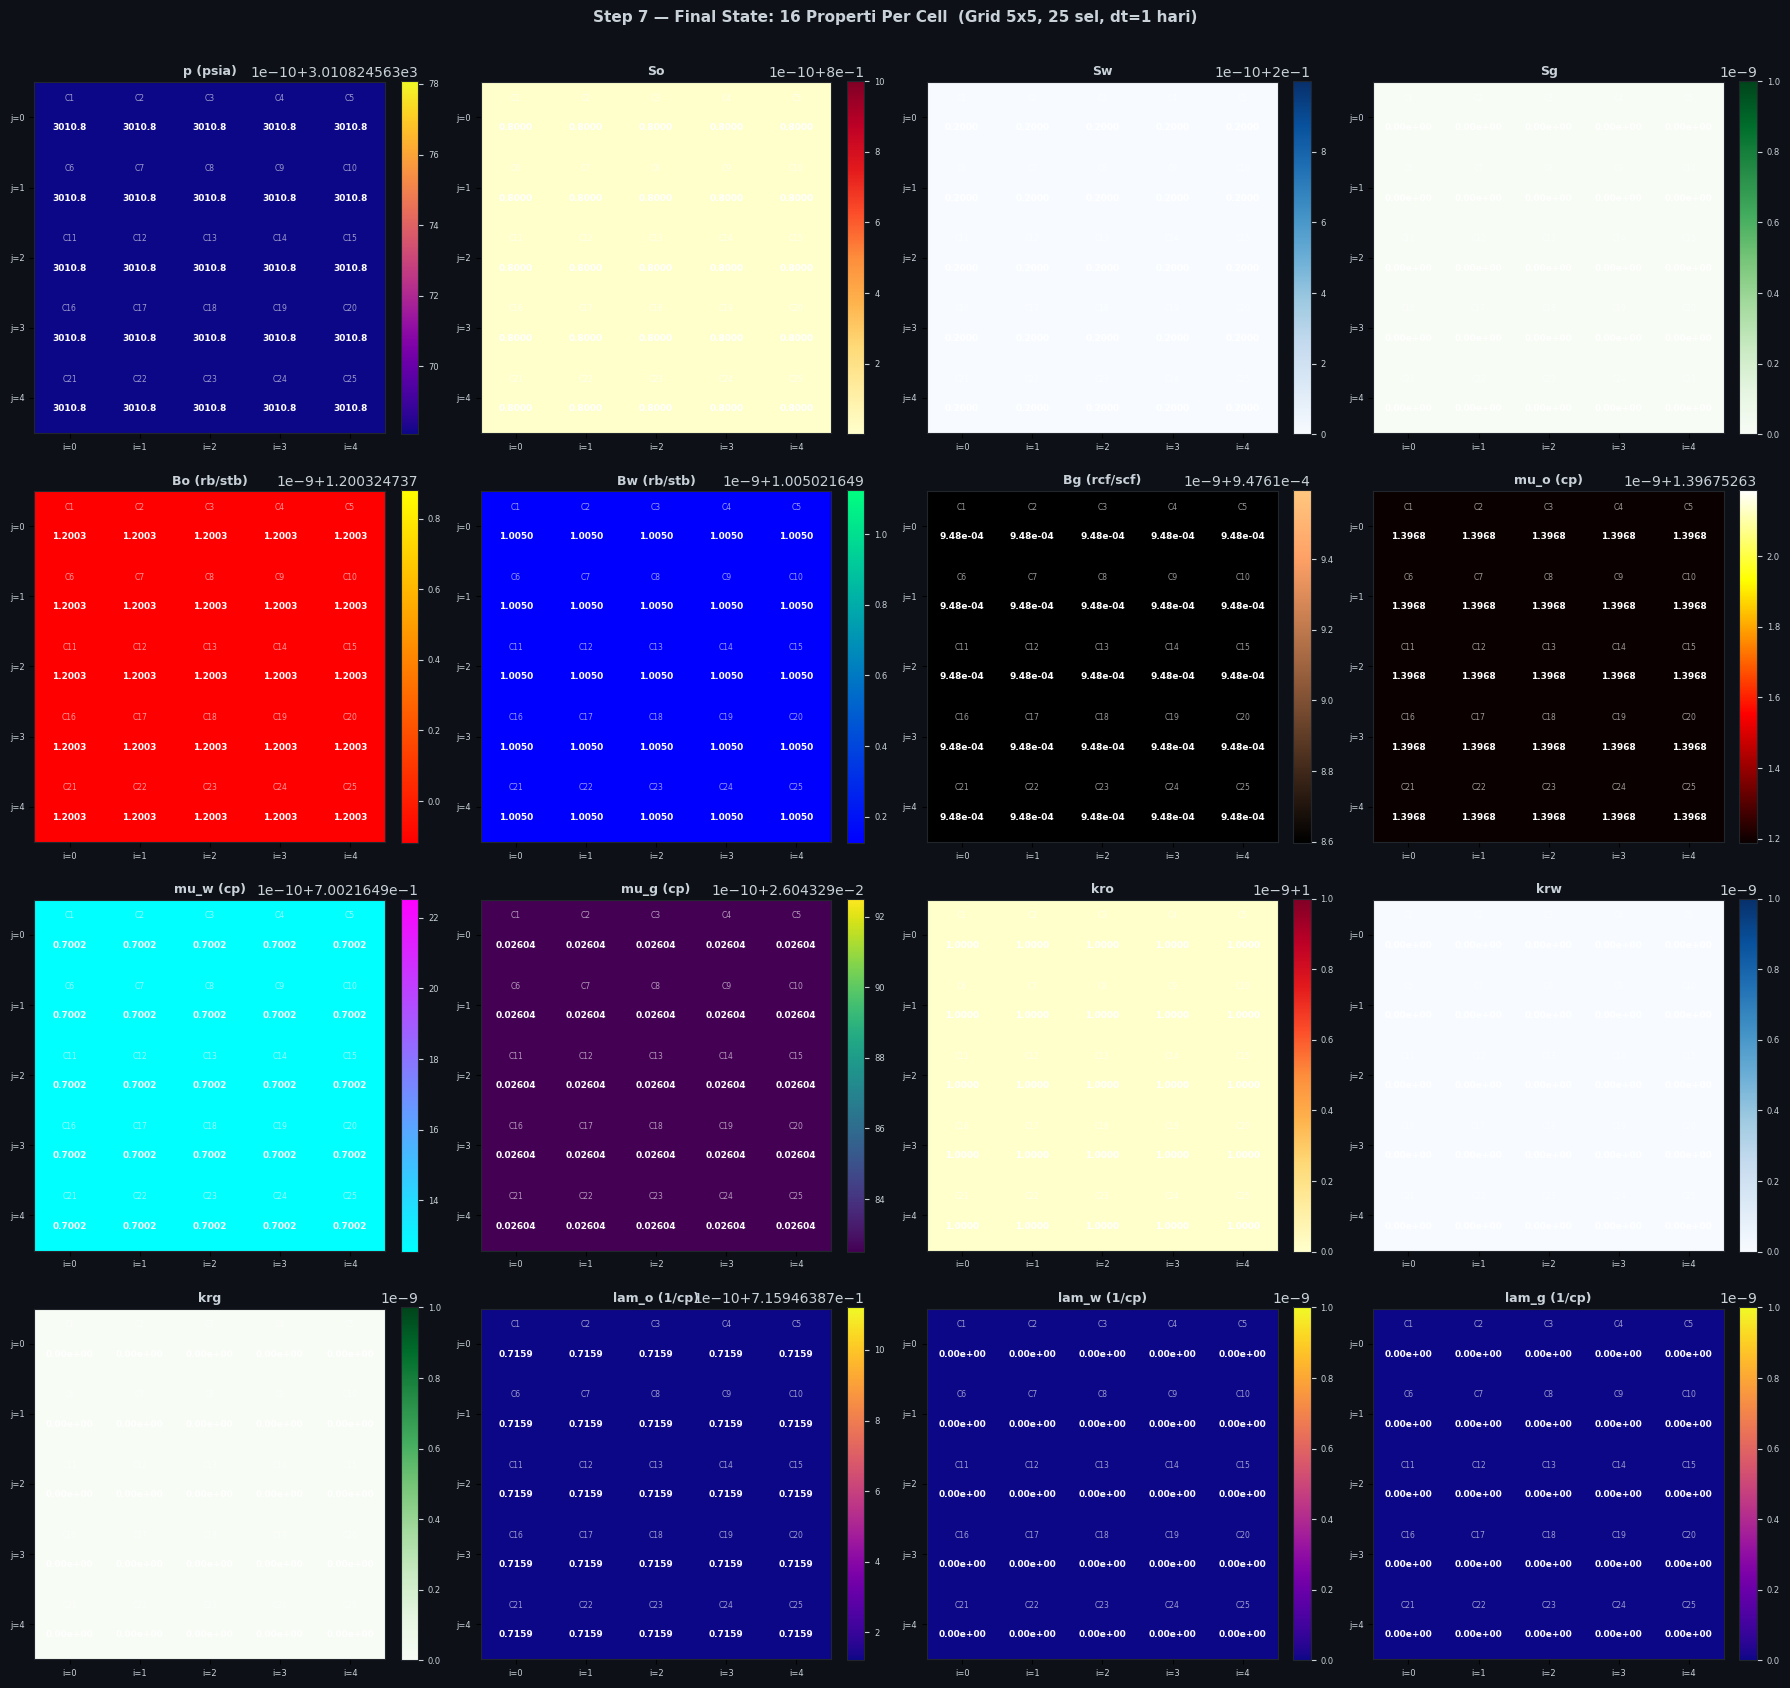

Grid 5x5 = 25 sel  |  dt = 1 hari  |  State: konvergen


,Cell,i,j,p (psia),So,Sw,Sg,Bo,Bw,Bg,mu_o,mu_w,mu_g,kro,krw,krg,lam_o,lam_w,lam_g,rho_o,rho_w,rho_g,Pcow,Pcgw
0,1,0,0,3010.82,0.80000,0.20000,0.00000,1.200325,1.005022,0.000948,1.39675,0.70022,0.02604,1.00000,0.00000,0.00000,0.715946,0.000000,0.000000,41.655,62.088,949.749,5.0000,0.0000
1,2,1,0,3010.82,0.80000,0.20000,0.00000,1.200325,1.005022,0.000948,1.39675,0.70022,0.02604,1.00000,0.00000,0.00000,0.715946,0.000000,0.000000,41.655,62.088,949.749,5.0000,0.0000
2,3,2,0,3010.82,0.80000,0.20000,0.00000,1.200325,1.005022,0.000948,1.39675,0.70022,0.02604,1.00000,0.00000,0.00000,0.715946,0.000000,0.000000,41.655,62.088,949.749,5.0000,0.0000
3,4,3,0,3010.82,0.80000,0.20000,0.00000,1.200325,1.005022,0.000948,1.39675,0.70022,0.02604,1.00000,0.00000,0.00000,0.715946,0.000000,0.000000,41.655,62.088,949.749,5.0000,0.0000
4,5,4,0,3010.82,0.80000,0.20000,0.00000,1.200325,1.005022,0.000948,1.39675,0.70022,0.02604,1.00000,0.00000,0.00000,0.715946,0.000000,0.000000,41.655,62.088,949.749,5.0000,0.0000
5,6,0,1,3010.82,0.80000,0.20000,0.00000,1.200325,1.005022,0.000948,1.39675,0.70022,0.02604,1.00000,0.00000,0.00000,0.715946,0.000000,0.000000,41.655,62.088,949.749,5.0000,0.0000
6,7,1,1,3010.82,0.80000,0.20000,0.00000,1.200325,1.005022,0.000948,1.39675,0.70022,0.02604,1.00000,0.00000,0.00000,0.715946,0.000000,0.000000,41.655,62.088,949.749,5.0000,0.0000
7,8,2,1,3010.82,0.80000,0.20000,0.00000,1.200325,1.005022,0.000948,1.39675,0.70022,0.02604,1.00000,0.00000,0.00000,0.715946,0.000000,0.000000,41.655,62.088,949.749,5.0000,0.0000
8,9,3,1,3010.82,0.80000,0.20000,0.00000,1.200325,1.005022,0.000948,1.39675,0.70022,0.02604,1.00000,0.00000,0.00000,0.715946,0.000000,0.000000,41.655,62.088,949.749,5.0000,0.0000
9,10,4,1,3010.82,0.80000,0.20000,0.00000,1.200325,1.005022,0.000948,1.39675,0.70022,0.02604,1.00000,0.00000,0.00000,0.715946,0.000000,0.000000,41.655,62.088,949.749,5.0000,0.0000


In [41]:
import matplotlib.pyplot as plt
import numpy as np

# ── Hitung semua properti final per cell (state konvergen Step 6) ─────────────
df_fin = evaluate_state(grid, state_step_1).copy()
df_fin = df_fin.merge(df_cells[['cell', 'i_index', 'j_index']], on='cell')

NX_ = rm.NX
NY_ = rm.NY
N_  = NX_ * NY_

# ── Properti yang diplot sebagai heatmap (4 kolom x 4 baris = 16 plot) ───────
PROPS = [
    ('pressure_psia', 'p (psia)',      'plasma'),
    ('so',            'So',            'YlOrRd'),
    ('sw',            'Sw',            'Blues'),
    ('sg',            'Sg',            'Greens'),
    ('bo',            'Bo (rb/stb)',   'autumn'),
    ('bw',            'Bw (rb/stb)',   'winter'),
    ('bg',            'Bg (rcf/scf)', 'copper'),
    ('mu_o',          'mu_o (cp)',     'hot'),
    ('mu_w',          'mu_w (cp)',     'cool'),
    ('mu_g',          'mu_g (cp)',     'viridis'),
    ('kro',           'kro',           'YlOrRd'),
    ('krw',           'krw',           'Blues'),
    ('krg',           'krg',           'Greens'),
    ('lam_o',         'lam_o (1/cp)', 'plasma'),
    ('lam_w',         'lam_w (1/cp)', 'plasma'),
    ('lam_g',         'lam_g (1/cp)', 'plasma'),
]

BG, TC, GC = '#0d1117', '#c9d1d9', '#21262d'
NCOLS = 4
NROWS = (len(PROPS) + NCOLS - 1) // NCOLS

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 4.5, NROWS * 4.2))
fig.patch.set_facecolor(BG)
axes_flat = axes.flatten()

for idx, (col, label, cmap) in enumerate(PROPS):
    ax = axes_flat[idx]
    ax.set_facecolor(BG)

    mat = np.full((NY_, NX_), np.nan)
    for _, r in df_fin.iterrows():
        mat[int(r['j_index']), int(r['i_index'])] = r[col]

    vlo, vhi = float(np.nanmin(mat)), float(np.nanmax(mat))
    if vlo == vhi:
        vhi = vlo + 1e-9

    im = ax.imshow(mat, cmap=cmap, aspect='equal', origin='upper',
                   vmin=vlo, vmax=vhi)

    for gj in range(NY_):
        for gi in range(NX_):
            v   = mat[gj, gi]
            cno = gj * NX_ + gi + 1
            if abs(v) >= 100:
                vtxt = f'{v:.1f}'
            elif abs(v) < 0.001:
                vtxt = f'{v:.2e}'
            elif abs(v) < 0.01:
                vtxt = f'{v:.5f}'
            elif abs(v) < 0.1:
                vtxt = f'{v:.5f}'
            elif abs(v) < 10:
                vtxt = f'{v:.4f}'
            else:
                vtxt = f'{v:.2f}'
            # nilai
            ax.text(gi, gj + 0.15, vtxt, ha='center', va='center',
                    fontsize=6.5, color='white', fontweight='bold')
            # label cell
            ax.text(gi, gj - 0.27, f'C{cno}', ha='center', va='center',
                    fontsize=5.5, color='#ffffff99')

    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(colors=TC, labelsize=6)
    cb.outline.set_edgecolor(GC)

    ax.set_title(label, color=TC, fontsize=9, fontweight='bold', pad=5)
    ax.set_xticks(range(NX_))
    ax.set_xticklabels([f'i={v}' for v in range(NX_)], color=TC, fontsize=6)
    ax.set_yticks(range(NY_))
    ax.set_yticklabels([f'j={v}' for v in range(NY_)], color=TC, fontsize=6)
    for sp in ax.spines.values():
        sp.set_color(GC)

for idx in range(len(PROPS), NROWS * NCOLS):
    axes_flat[idx].set_visible(False)

fig.suptitle(
    f'Step 7 — Final State: 16 Properti Per Cell  (Grid {NX_}x{NY_}, {N_} sel, dt={rm.DT_INITIAL:.0f} hari)',
    color=TC, fontsize=11, fontweight='bold', y=1.004
)
plt.tight_layout()
plt.show()

# ── Tabel lengkap: semua properti numerik per cell ───────────────────────────
_COLS = ['cell', 'i_index', 'j_index',
         'pressure_psia', 'so', 'sw', 'sg',
         'bo', 'bw', 'bg',
         'mu_o', 'mu_w', 'mu_g',
         'kro', 'krw', 'krg',
         'lam_o', 'lam_w', 'lam_g',
         'rho_o', 'rho_w', 'rho_g',
         'pcow', 'pcgw']

_REN = {
    'cell': 'Cell', 'i_index': 'i', 'j_index': 'j',
    'pressure_psia': 'p (psia)', 'so': 'So', 'sw': 'Sw', 'sg': 'Sg',
    'bo': 'Bo', 'bw': 'Bw', 'bg': 'Bg',
    'mu_o': 'mu_o', 'mu_w': 'mu_w', 'mu_g': 'mu_g',
    'kro': 'kro', 'krw': 'krw', 'krg': 'krg',
    'lam_o': 'lam_o', 'lam_w': 'lam_w', 'lam_g': 'lam_g',
    'rho_o': 'rho_o', 'rho_w': 'rho_w', 'rho_g': 'rho_g',
    'pcow': 'Pcow', 'pcgw': 'Pcgw',
}

_FMT = {
    'p (psia)': '{:.2f}',
    'So': '{:.5f}', 'Sw': '{:.5f}', 'Sg': '{:.5f}',
    'Bo': '{:.6f}', 'Bw': '{:.6f}', 'Bg': '{:.6f}',
    'mu_o': '{:.5f}', 'mu_w': '{:.5f}', 'mu_g': '{:.5f}',
    'kro': '{:.5f}', 'krw': '{:.5f}', 'krg': '{:.5f}',
    'lam_o': '{:.6f}', 'lam_w': '{:.6f}', 'lam_g': '{:.6f}',
    'rho_o': '{:.3f}', 'rho_w': '{:.3f}', 'rho_g': '{:.3f}',
    'Pcow': '{:.4f}', 'Pcgw': '{:.4f}',
}

_GRAD = {
    'p (psia)': 'plasma',
    'So': 'YlOrRd', 'Sw': 'Blues', 'Sg': 'Greens',
    'kro': 'YlOrRd', 'krw': 'Blues', 'krg': 'Greens',
}

df_tbl = df_fin[_COLS].rename(columns=_REN)

_stl = df_tbl.style.format(_FMT)
for _c, _cm in _GRAD.items():
    _stl = _stl.background_gradient(subset=[_c], cmap=_cm, axis=0)

_stl = (
    _stl
    .set_properties(**{
        'background-color': '#0d1117',
        'color': '#c9d1d9',
        'border': '1px solid #21262d',
        'text-align': 'center',
        'font-size': '11px',
        'padding': '4px 8px',
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#161b22'),
            ('color', '#58a6ff'),
            ('font-weight', 'bold'),
            ('border', '1px solid #21262d'),
            ('text-align', 'center'),
            ('font-size', '11px'),
        ]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('color', '#c9d1d9'),
            ('font-size', '12px'),
            ('font-weight', 'bold'),
            ('padding', '8px'),
        ]},
    ])
    .set_caption(
        f'Tabel Semua Properti PVT Per Cell  |  Grid {NX_}x{NY_}  |  {N_} sel  |  dt={rm.DT_INITIAL:.0f} hari'
    )
)

print(f'Grid {NX_}x{NY_} = {N_} sel  |  dt = {rm.DT_INITIAL:.0f} hari  |  State: konvergen')
display(_stl)
